<div class="alert alert-block alert-info">
<b>🔄Комментарий студента:</b> 
Привет, меня зовут Оксана. Это мой Сборный проект №1✔
</div>

- Описание проекта:

- Вы работаете в интернет-магазине «Стримчик», который продаёт по всему миру компьютерные игры. Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation). Вам нужно выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.
- Перед вами данные до 2016 года. Представим, что сейчас декабрь 2016 г., и вы планируете кампанию на 2017-й. Нужно отработать принцип работы с данными. Неважно, прогнозируете ли вы продажи на 2017 год по данным 2016-го или же 2027-й — по данным 2026 года.
- В наборе данных попадается аббревиатура ESRB (Entertainment Software Rating Board) — это ассоциация, определяющая возрастной рейтинг компьютерных игр. ESRB оценивает игровой контент и присваивает ему подходящую возрастную категорию, например, «Для взрослых», «Для детей младшего возраста» или «Для подростков».

Описание данных
- Name — название игры
- Platform — платформа
- Year_of_Release — год выпуска
- Genre — жанр игры
- NA_sales — продажи в Северной Америке (миллионы проданных копий)
- EU_sales — продажи в Европе (миллионы проданных копий)
- JP_sales — продажи в Японии (миллионы проданных копий)
- Other_sales — продажи в других странах (миллионы проданных копий)
- Critic_Score — оценка критиков (максимум 100)
- User_Score — оценка пользователей (максимум 10)
- Rating — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.

 - EC («Early childhood») — «Для детей младшего возраста»
 - E («Everyone») — «Для всех»
 - K-A ("Kids to Adults") — вариация категории «Для всех»
 - E10+ («Everyone 10 and older») — «Для всех от 10 лет и старше»
 - T («Teen») — «Подросткам»
 - M («Mature») — «Для взрослых 17+»
 - AO («Adults Only 18+») — «Только для взрослых»
 - RP («Rating Pending») — «Рейтинг ожидается»

План действий:
- импортируем библиотеки
- загружаем данные
- проводим предобработку данных
- проводим иследовательский анализ
- составим портрет пользователя каждого региона
- проводим статистический анализ
 - проверим гипотезы H0, Н1
- сформируем вывод

In [1]:
# импортируем нужные библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

from scipy import stats as st

warnings.filterwarnings("ignore")  # бережем глаза от ненужных предупреждений


### Шаг 1. Откройте файл с данными и изучите общую информацию

Путь к файлу: /datasets/games.csv. Скачать датасет (https://code.s3.yandex.net/datasets/games.csv)

In [2]:
# чтение файла data, разделитель у нас запятая
try:
    #локальный файл
    data = pd.read_csv('/datasets/games.csv', sep=',')
except:
    # файл онлайн
    data = pd.read_csv('https://code.s3.yandex.net/datasets/games.csv', sep=',')
    
# настройки Pandas для вывода всех столбцов 
pd.set_option('display.max_columns', None)

# установка максимального количества строк для отображения
pd.set_option(
    "display.max_rows", 50
)  # по умолчанию 50, можно изменить при необходимости
# установка ширины колонок
pd.set_option(
    "display.max_colwidth", 100
)  # по умолчанию 50, можно изменить при необходимости
# установка ширины дисплея
pd.set_option(
    "display.width", 1000
)  # Устанавливаем достаточную ширину для отображения всех колонок

In [3]:
# выведим на экран
display(data)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [4]:
# выведим на эксран инфо датафрема
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


#### Вывод по загрузке данных:
- 11 столбцов с данными
- название столбцов не по питонски
- есть пропущеные значения
- 16715 строк 
- тип данных разный


### Шаг 2. Подготовьте данные

#### Замените названия столбцов (приведите к нижнему регистру);

In [5]:
# колонки под один формат сделаем
data.columns = data.columns.str.lower().str.replace(" ", "_")

In [6]:
# приведем к нижнему регистру названия в стобцах через цикл
for column_name in ["name", "platform", "genre", "rating"]:
    data[column_name] = data[column_name].str.lower()

In [7]:
# выведим на эксран инфо датафрема
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


#### Работа с дубликатами

In [8]:
data.duplicated().sum()

0

In [9]:
# удалим полные дубликаты
#data = data.drop_duplicates()

<div class="alert alert-block alert-info">
<b>🔄Комментарий студента:</b> 
явных дубликатов нет, удалять и не надо было, закоментировала код с удалением
</div>

In [10]:
# выведим не явные дубликаты кол-во
data[data.duplicated(['name', 'platform', 'year_of_release'])].count()

name               1
platform           2
year_of_release    2
genre              1
na_sales           2
eu_sales           2
jp_sales           2
other_sales        2
critic_score       1
user_score         1
rating             1
dtype: int64

In [11]:
# выведим на экран
data[data.duplicated(['name', 'platform', 'year_of_release'])]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
14244,NaN,gen,1993.0,NaN,0.0,0.00,0.03,0.0,NaN,NaN,NaN
16230,madden nfl 13,ps3,2012.0,sports,0.0,0.01,0.00,0.0,83.0,5.5,e


In [12]:
# удалим не явные дубликаты
data = data.drop_duplicates(['name', 'platform', 'year_of_release'])

In [13]:
# выведим на экран
data[data.duplicated(['name', 'platform', 'year_of_release'])]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating


In [14]:
data.duplicated().sum()

0

Дубликатов нет

#### Работа с пропусками в данных

In [15]:
# выведим где пропуски
data.isnull().sum()*100/len(data)

name                0.005983
platform            0.000000
year_of_release     1.609526
genre               0.005983
na_sales            0.000000
eu_sales            0.000000
jp_sales            0.000000
other_sales         0.000000
critic_score       51.319332
user_score         40.088554
rating             40.477473
dtype: float64

In [16]:
# добавила код от ревьюера посмотреть
report = data.isna().sum().to_frame()
report = report.rename(columns = {0: 'missing_values'})
report['% of total'] = (report['missing_values'] / data.shape[0]).round(2)
report.sort_values(by = 'missing_values', ascending = False)

,missing_values,% of total
critic_score,8577,0.51
rating,6765,0.40
user_score,6700,0.40
year_of_release,269,0.02
name,1,0.00
genre,1,0.00
platform,0,0.00
na_sales,0,0.00
eu_sales,0,0.00
jp_sales,0,0.00


<div class="alert alert-block alert-info">
<b>🔄Комментарий студента:</b> 
о супе как, буду применять
</div>

Пропуски в 6 столбцах 

Столбец name, удалим строку с пропущеным названием

In [17]:
# уникальные значения
data['name'].unique()

array(['wii sports', 'super mario bros.', 'mario kart wii', ...,
       'woody woodpecker in crazy castle 5', 'lma manager 2007',
       'haitaka no psychedelica'], dtype=object)

In [18]:
# удалим строку пустую
data = data.dropna(subset=['name'])

Столбец year_of_release, удалим строки с пропущеным значениями годов

In [19]:
# уникальные значения
data['year_of_release'].unique()

array([2006., 1985., 2008., 2009., 1996., 1989., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2016., 2003., 1986., 2000.,   nan, 1995., 1991., 1981., 1987.,
       1980., 1983.])

In [20]:
# удалим строку пустую
data = data.dropna(subset=['year_of_release'])

Столбец genre , удалим строки с пропущеными значениями жанра

In [21]:
# уникальные значения
data['genre'].unique()

array(['sports', 'platform', 'racing', 'role-playing', 'puzzle', 'misc',
       'shooter', 'simulation', 'action', 'fighting', 'adventure',
       'strategy'], dtype=object)

In [22]:
# удалим строку пустую
data = data.dropna(subset=['genre'])

Столбец critic_score, половина данных пустая, заменим на -1

In [23]:
# уникальные значения
data['critic_score'].unique()

array([76., nan, 82., 80., 89., 58., 87., 91., 61., 97., 95., 77., 88.,
       83., 94., 93., 85., 86., 98., 96., 90., 84., 73., 74., 78., 92.,
       71., 72., 68., 62., 49., 67., 81., 66., 56., 79., 70., 59., 64.,
       75., 60., 63., 69., 50., 25., 42., 44., 55., 48., 57., 29., 47.,
       65., 54., 20., 53., 37., 38., 33., 52., 30., 32., 43., 45., 51.,
       40., 46., 39., 34., 41., 36., 31., 27., 35., 26., 19., 28., 23.,
       24., 21., 17., 13.])

In [24]:
# заменим значение
data['critic_score'] = data['critic_score'].fillna(-1)

Столбец user_score, половина данных пустая, заменим на -1

In [25]:
# уникальные значения
data['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [26]:
# заменим значение
data['user_score'] = data['user_score'].fillna(-1)

Столбец user_score, половина данных пустая, заменим на -1

In [27]:
# заменим значение
data.loc[data['user_score'] == 'tbd', 'user_score'] = -1

In [28]:
# уникальные значения
data['user_score'].unique()

array(['8', -1, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', '8.8', '6.9', '9.4', '6.8', '6.1',
       '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6', '3.7',
       '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9', '3.1',
       '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3', '2.7',
       '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0', '1.6',
       '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2', '2.3',
       '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'], dtype=object)

Столбец rating, 'tbd' - to be determined "будет определено позже",  заменим на -1

In [29]:
# заменим значение
data['rating'] = data['rating'].fillna('unknown')

In [30]:
# выведим где пропуски
data.isna().sum()

name               0
platform           0
year_of_release    0
genre              0
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
dtype: int64

#### Изменим тип данных

In [31]:
# выведим на эксран инфо датафрема
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16443 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16443 non-null  object 
 1   platform         16443 non-null  object 
 2   year_of_release  16443 non-null  float64
 3   genre            16443 non-null  object 
 4   na_sales         16443 non-null  float64
 5   eu_sales         16443 non-null  float64
 6   jp_sales         16443 non-null  float64
 7   other_sales      16443 non-null  float64
 8   critic_score     16443 non-null  float64
 9   user_score       16443 non-null  object 
 10  rating           16443 non-null  object 
dtypes: float64(6), object(5)
memory usage: 1.5+ MB


In [32]:
# выведим на эксран 5 строк
data.head(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,wii sports,wii,2006.0,sports,41.36,28.96,3.77,8.45,76.0,8,e
1,super mario bros.,nes,1985.0,platform,29.08,3.58,6.81,0.77,-1.0,-1,unknown
2,mario kart wii,wii,2008.0,racing,15.68,12.76,3.79,3.29,82.0,8.3,e
3,wii sports resort,wii,2009.0,sports,15.61,10.93,3.28,2.95,80.0,8,e
4,pokemon red/pokemon blue,gb,1996.0,role-playing,11.27,8.89,10.22,1.00,-1.0,-1,unknown


Столбец year_of_release	переведем в int

In [33]:
# изменим тип данных
data['year_of_release'] = data['year_of_release'].astype('int32')

Столбец critic_score переведем в int

In [34]:
# изменим тип данных
data['critic_score'] = data['critic_score'].astype('int32')

Столбец user_score переведем в float

In [35]:
# изменим тип данных
data['user_score'] = data['user_score'].astype('float64')

In [36]:
# выведим на эксран инфо датафрема
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16443 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16443 non-null  object 
 1   platform         16443 non-null  object 
 2   year_of_release  16443 non-null  int32  
 3   genre            16443 non-null  object 
 4   na_sales         16443 non-null  float64
 5   eu_sales         16443 non-null  float64
 6   jp_sales         16443 non-null  float64
 7   other_sales      16443 non-null  float64
 8   critic_score     16443 non-null  int32  
 9   user_score       16443 non-null  float64
 10  rating           16443 non-null  object 
dtypes: float64(5), int32(2), object(4)
memory usage: 1.4+ MB


In [37]:
# выведим на эксран 5 строк
data.head(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,wii sports,wii,2006,sports,41.36,28.96,3.77,8.45,76,8.0,e
1,super mario bros.,nes,1985,platform,29.08,3.58,6.81,0.77,-1,-1.0,unknown
2,mario kart wii,wii,2008,racing,15.68,12.76,3.79,3.29,82,8.3,e
3,wii sports resort,wii,2009,sports,15.61,10.93,3.28,2.95,80,8.0,e
4,pokemon red/pokemon blue,gb,1996,role-playing,11.27,8.89,10.22,1.00,-1,-1.0,unknown


#### Посчитайте суммарные продажи во всех регионах и запишите их в отдельный столбец.

создадим столбец и добавм туда сумму столбцов
4 na_sales 
5 eu_sales 
6 jp_sales 
7 other_sales 

In [38]:
# добавим столбец с сумой всех столбцов sales 
data['sales_total'] = data['na_sales']+data['eu_sales']+data['jp_sales']+data['other_sales']

In [39]:
data['sales_total'].sum()

8814.359999999999

In [40]:
display(data.head(5))

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales_total
0,wii sports,wii,2006,sports,41.36,28.96,3.77,8.45,76,8.0,e,82.54
1,super mario bros.,nes,1985,platform,29.08,3.58,6.81,0.77,-1,-1.0,unknown,40.24
2,mario kart wii,wii,2008,racing,15.68,12.76,3.79,3.29,82,8.3,e,35.52
3,wii sports resort,wii,2009,sports,15.61,10.93,3.28,2.95,80,8.0,e,32.77
4,pokemon red/pokemon blue,gb,1996,role-playing,11.27,8.89,10.22,1.00,-1,-1.0,unknown,31.38


In [41]:
display(data.tail(5))

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales_total
16710,samurai warriors: sanada maru,ps3,2016,action,0.00,0.00,0.01,0.0,-1,-1.0,unknown,0.01
16711,lma manager 2007,x360,2006,sports,0.00,0.01,0.00,0.0,-1,-1.0,unknown,0.01
16712,haitaka no psychedelica,psv,2016,adventure,0.00,0.00,0.01,0.0,-1,-1.0,unknown,0.01
16713,spirits & spells,gba,2003,platform,0.01,0.00,0.00,0.0,-1,-1.0,unknown,0.01
16714,winning post 8 2016,psv,2016,simulation,0.00,0.00,0.01,0.0,-1,-1.0,unknown,0.01


#### Вывод подготовки данных:
- удалили явные и не явные дубликаты
- удалили пропуски по столбцам name, year_of_release, genre 
- пропущеные значение заменили на -1
- значение tbd заменили на -1
- заменили пустые значения в столбце rating на 'unknown' 
- сумарные продажи получлись раны 8814 млн.



### Шаг 3. Проведите исследовательский анализ данных

- Посмотрите, сколько игр выпускалось в разные годы. Важны ли данные за все периоды?
- Посмотрите, как менялись продажи по платформам. Выберите платформы с наибольшими суммарными продажами и постройте распределение по годам. За какой характерный срок появляются новые и исчезают старые платформы?
- Возьмите данные за соответствующий актуальный период. Актуальный период определите самостоятельно в результате исследования предыдущих вопросов. Основной фактор — эти данные помогут построить прогноз на 2017 год.
- Не учитывайте в работе данные за предыдущие годы.
- Какие платформы лидируют по продажам, растут или падают? Выберите несколько потенциально прибыльных платформ.
- Постройте график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Опишите результат.
- Посмотрите, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. Постройте диаграмму рассеяния и посчитайте корреляцию между отзывами и продажами. Сформулируйте выводы.
- Соотнесите выводы с продажами игр на других платформах.
- Посмотрите на общее распределение игр по жанрам. Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?

In [42]:
# супер код обнуружения числовых столбцов
numeric_columns = data.select_dtypes(include='number').columns

In [43]:
# выведим название столбцов с числовыми данными
numeric_columns

Index(['year_of_release', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'sales_total'], dtype='object')

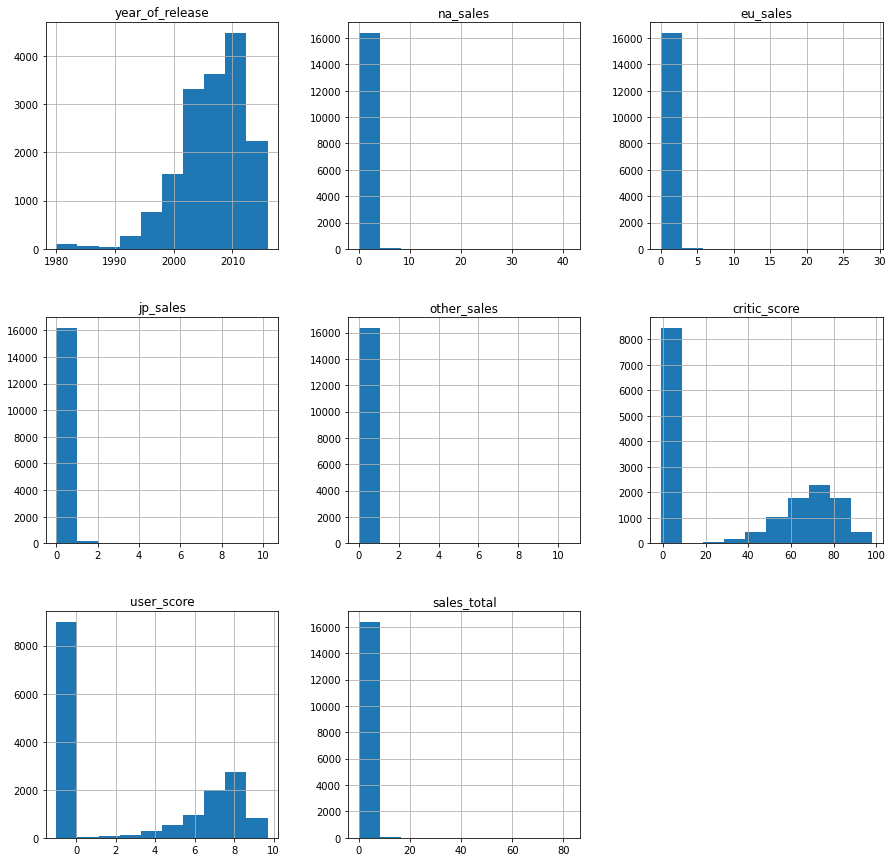

In [44]:
# построим супер гисторгаммы для списка numeric_cols
data[numeric_columns].hist(figsize=(15, 15))

plt.show()

#### Cколько игр выпускалось в разные годы?

In [45]:
# выведим сводную статистику
data.describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,sales_total
count,16443.000000,16443.000000,16443.000000,16443.000000,16443.000000,16443.000000,16443.000000,16443.000000
mean,2006.485921,0.264028,0.145939,0.078492,0.047597,32.976829,2.687910,0.536055
std,5.875546,0.818400,0.506731,0.311109,0.188011,36.301955,4.170193,1.558828
min,1980.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.060000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,-1.000000,-1.000000,0.170000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,70.000000,7.300000,0.470000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000,9.700000,82.540000


In [46]:
#создадим групировку сортировка по году
data.groupby('year_of_release')['name'].count().reset_index().sort_values(by='year_of_release', ascending=False)

,year_of_release,name
36,2016,502
35,2015,606
34,2014,581
33,2013,544
32,2012,652
31,2011,1136
30,2010,1255
29,2009,1426
28,2008,1427
27,2007,1197


In [47]:
#создадим групировку сортировка по кол-ву
game_count = data.groupby('year_of_release')['name'].count().reset_index().sort_values(by='name', ascending=False)
game_count

,year_of_release,name
28,2008,1427
29,2009,1426
30,2010,1255
27,2007,1197
31,2011,1136
26,2006,1006
25,2005,939
22,2002,829
23,2003,775
24,2004,762


Игры выпускаются с 1980 года по 2016 год

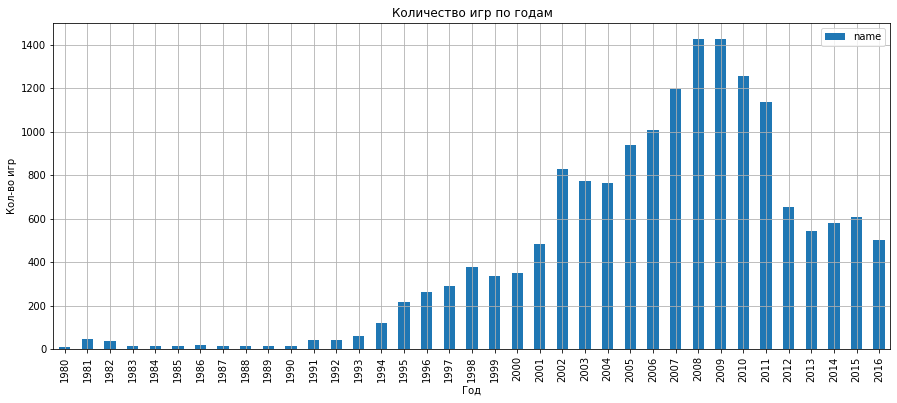

In [48]:
# выведим гистограмму по годам и играми
(
    data
    .pivot_table(index='year_of_release', values='name', aggfunc='count')
    .plot(kind='bar', grid=True, figsize=(15, 6))
)
plt.title('Количество игр по годам')
plt.xlabel('Год')
plt.ylabel('Кол-во игр')

plt.show()


In [49]:
# выведим статистику
data['year_of_release'].describe()

count    16443.000000
mean      2006.485921
std          5.875546
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2016.000000
Name: year_of_release, dtype: float64

- Больше всего продаж кол-ва игр в 2008 году
- до 2008 года восходящий тренд
- после 2009 года до 2012 года нисходящий тренд
- с 2012 года тренд прямой (линейный)




#### Посмотрите, как менялись продажи по платформам. Выберите платформы с наибольшими суммарными продажами и постройте распределение по годам.


In [50]:
#создадим групировку сортировка по платформам
data.groupby('platform')['sales_total'].count().reset_index().sort_values(by='sales_total', ascending=False).head(10)

,platform,sales_total
16,ps2,2127
4,ds,2121
17,ps3,1305
25,wii,1286
28,x360,1232
19,psp,1193
15,ps,1190
13,pc,957
6,gba,811
29,xb,803


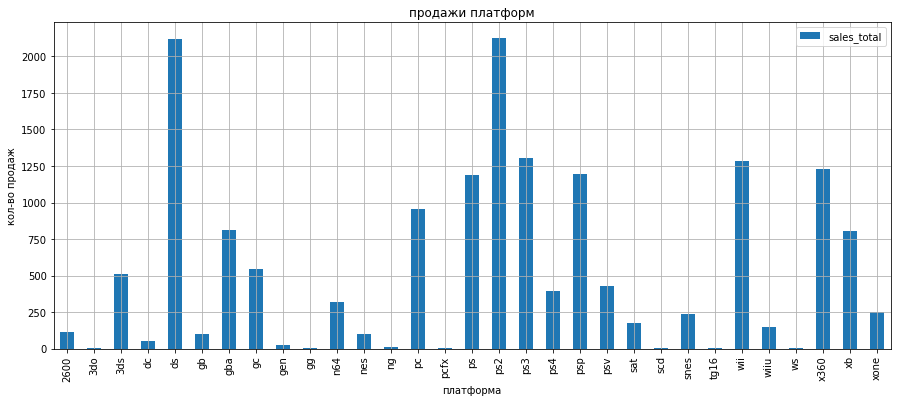

In [51]:
# выведим гистограмму по годам и играми
(
    data
    .pivot_table(index='platform', values='sales_total', aggfunc='count')
    .plot(kind='bar', grid=True, figsize=(15, 6))
)
plt.title('продажи платформ')
plt.xlabel('платформа')
plt.ylabel('кол-во продаж')

plt.show()


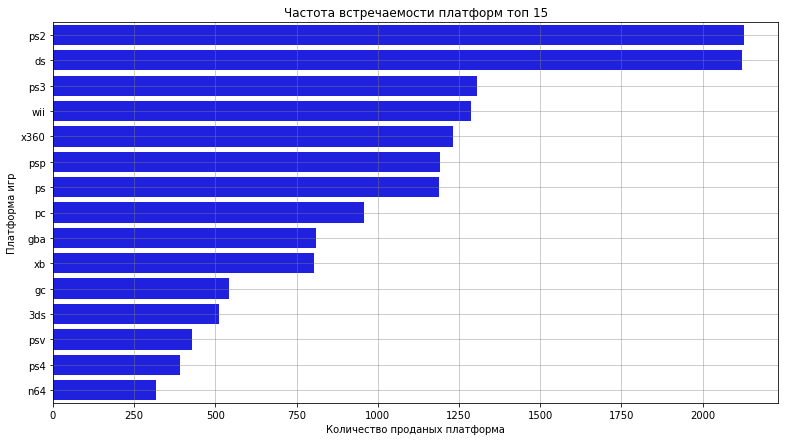

In [52]:
# настройка размера фигуры
plt.figure(figsize=(13, 7))

# построим супер пупер гистограмму
sns.barplot(x="sales_total",
            y="platform",
            data=data.groupby('platform')['sales_total'].count().reset_index().sort_values(by='sales_total', ascending=False).head(15),
            color='#0000FF' # выбрать цвет
)
# установка заголовка графика
plt.title('Частота встречаемости платформ топ 15')
# подписи для оси X
plt.xlabel('Количество проданых платформа')
# подписи для оси Y
plt.ylabel('Платформа игр')
# сетка на графике, серого цвета с прозрачностью 0.5
plt.grid(color='grey', axis='both', alpha=0.5)
plt.show()

Самая продаваяемая платформа PS2 в период с 1980 года по 2016 год

In [53]:
# создадим список платформ топ
platform_top = data.groupby('platform')['sales_total'].count().reset_index().sort_values(by='sales_total', ascending=False).head(5)
platform_top = platform_top['platform']
platform_top

16     ps2
4       ds
17     ps3
25     wii
28    x360
Name: platform, dtype: object

Построим график по 5 платформам

In [54]:
# групировка по платформа
platform_ps2 = data[data['platform']=='ps2'].groupby('year_of_release')['sales_total'].sum()
platform_ps2

year_of_release
2000     39.17
2001    166.43
2002    205.38
2003    184.31
2004    211.81
2005    160.66
2006    103.42
2007     75.99
2008     53.90
2009     26.40
2010      5.64
2011      0.45
Name: sales_total, dtype: float64

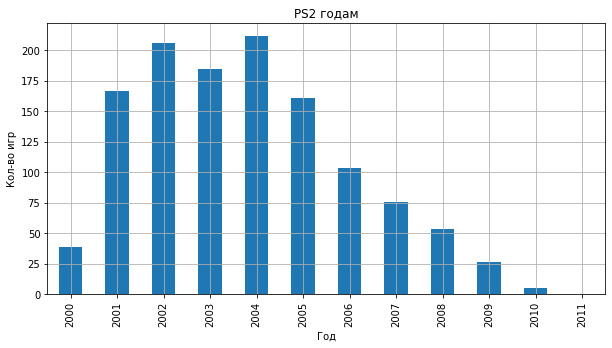

In [55]:
# выведим гистограмму по годам и играми
(
    platform_ps2
    .plot(kind='bar', grid=True, figsize=(10, 5))
)
plt.title('PS2 годам')
plt.xlabel('Год')
plt.ylabel('Кол-во игр')

plt.show()


начались продажи в 2000 году, росли до 2004 года, потом пошло на убывание до 2011 года

In [56]:
# групировка по платформа
platform_ds = data[data['platform']=='ds'].groupby('year_of_release')['sales_total'].sum()
platform_ds

year_of_release
1985      0.02
2004     17.27
2005    130.14
2006    119.81
2007    146.94
2008    145.31
2009    119.54
2010     85.02
2011     26.18
2012     11.01
2013      1.54
Name: sales_total, dtype: float64

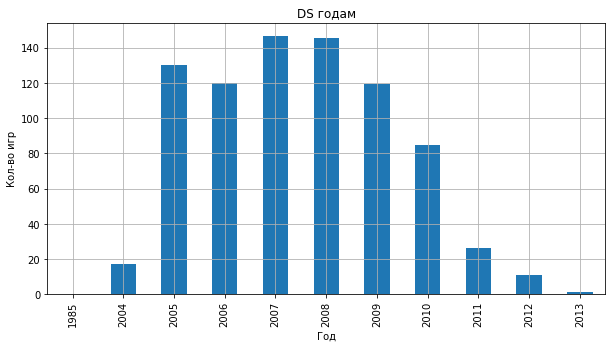

In [57]:
# выведим гистограмму по годам и играми
(
    platform_ds
    .plot(kind='bar', grid=True, figsize=(10, 5))
)
plt.title('DS годам')
plt.xlabel('Год')
plt.ylabel('Кол-во игр')

plt.show()

По DS видим что в 1985 году лишнее значение, удалим его

In [58]:
# выведем на экран
data.query('platform == "ds" and year_of_release < 1990')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales_total
15957,strongest tokyo university shogi ds,ds,1985,action,0.0,0.0,0.02,0.0,-1,-1.0,unknown,0.02


In [59]:
# удалим столбец 15957
data = data.drop(index = 15957)

In [60]:
# групировка по платформа
platform_ds = data[data['platform']=='ds'].groupby('year_of_release')['sales_total'].sum()
platform_ds

year_of_release
2004     17.27
2005    130.14
2006    119.81
2007    146.94
2008    145.31
2009    119.54
2010     85.02
2011     26.18
2012     11.01
2013      1.54
Name: sales_total, dtype: float64

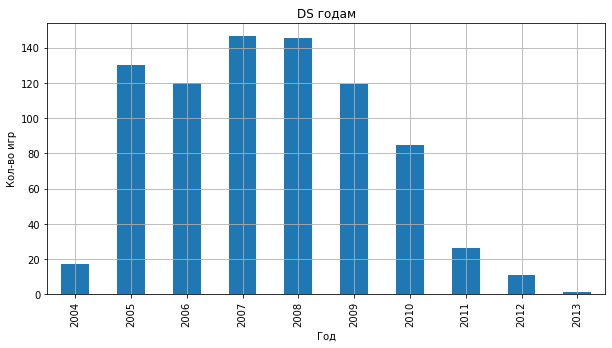

In [61]:
# выведим гистограмму по годам и играми
(
    platform_ds
    .plot(kind='bar', grid=True, figsize=(10, 5))
)
plt.title('DS годам')
plt.xlabel('Год')
plt.ylabel('Кол-во игр')

plt.show()

с 2004 года по 2007 год, был рост, с 2008 года тренд был убывающим.

In [62]:
# групировка по платформа
platform_ps3 = data[data['platform']=='ps3'].groupby('year_of_release')['sales_total'].sum()
platform_ps3

year_of_release
2006     20.96
2007     73.19
2008    118.52
2009    130.93
2010    142.17
2011    156.78
2012    107.35
2013    113.25
2014     47.76
2015     16.82
2016      3.60
Name: sales_total, dtype: float64

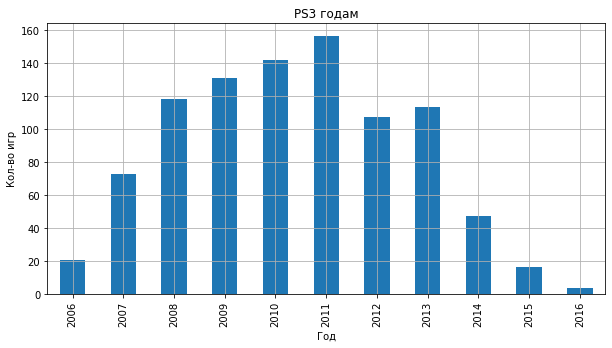

In [63]:
# выведим гистограмму по годам и играми
(
    platform_ps3
    .plot(kind='bar', grid=True, figsize=(10, 5))
)
plt.title('PS3 годам')
plt.xlabel('Год')
plt.ylabel('Кол-во игр')

plt.show()

In [64]:
# групировка по платформа
platform_wii = data[data['platform']=='wii'].groupby('year_of_release')['sales_total'].sum()
platform_wii

year_of_release
2006    137.15
2007    152.77
2008    171.32
2009    206.97
2010    127.95
2011     59.65
2012     21.71
2013      8.59
2014      3.75
2015      1.14
2016      0.18
Name: sales_total, dtype: float64

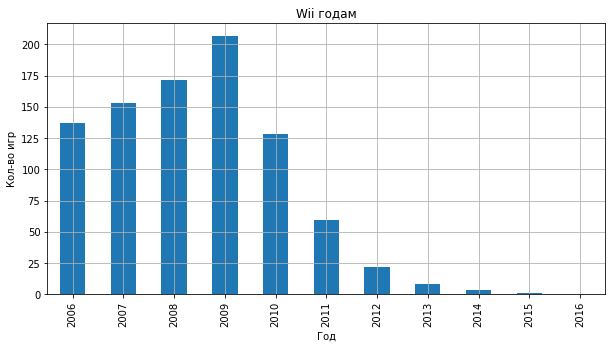

In [65]:
# выведим гистограмму по годам и играми
(
    platform_wii
    .plot(kind='bar', grid=True, figsize=(10, 5))
)
plt.title('Wii годам')
plt.xlabel('Год')
plt.ylabel('Кол-во игр')

plt.show()

In [66]:
# групировка по платформа
platform_x360 = data[data['platform']=='x360'].groupby('year_of_release')['sales_total'].sum()
platform_x360

year_of_release
2005      8.25
2006     51.62
2007     95.41
2008    135.26
2009    120.29
2010    170.03
2011    143.84
2012     99.74
2013     88.58
2014     34.74
2015     11.96
2016      1.52
Name: sales_total, dtype: float64

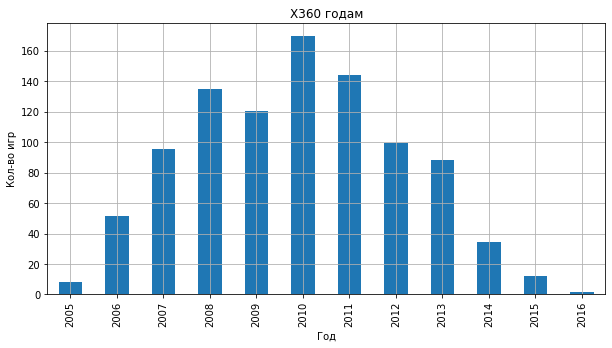

In [67]:
# выведим гистограмму по годам и играми
(
    platform_x360
    .plot(kind='bar', grid=True, figsize=(10, 5))
)
plt.title('X360 годам')
plt.xlabel('Год')
plt.ylabel('Кол-во игр')

plt.show()

Мы выбрали топ 5 платформ по количеству проданых игр для них, но на графиках видим только убывающий тренд. В середини пик и потом спад игровой платформы с играми.

#### За какой характерный срок появляются новые и исчезают старые платформы?

In [68]:
# сводна макс и мин годов по платформам
#data_term = data.pivot_table(index='platform',values=('year_of_release', 'sales_total'),aggfunc=('max','min')).sort_values(by='sales_total', ascending=False)


# создадим сводную через пивот супер пупер код назначим на опреденные столцы варианты параметров
data_term = data.pivot_table(
    index=('platform'),
    values=('year_of_release', 'sales_total'),
    aggfunc=({'year_of_release':{'min', 'max'}, 
             'sales_total':'sum',})
)
# переименнуем столбцы
data_term.columns = ['sales_total_sum','year_of_release_max','year_of_release_min']

# выведим на экран
data_term.sort_values(by='sales_total_sum', ascending=False)

,sales_total_sum,year_of_release_max,year_of_release_min
platform,,,
ps2,1233.56,2011,2000
x360,961.24,2016,2005
ps3,931.33,2016,2006
wii,891.18,2016,2006
ds,802.76,2013,2004
ps,727.58,2003,1994
ps4,314.14,2016,2013
gba,312.88,2007,2000
psp,289.53,2015,2004


In [69]:
# добавим столбец разницы data_term
data_term['p_term'] = data_term['year_of_release_max'] - data_term['year_of_release_min']
data_term = data_term.sort_values(by='sales_total_sum', ascending=False)
data_term

,sales_total_sum,year_of_release_max,year_of_release_min,p_term
platform,,,,
ps2,1233.56,2011,2000,11
x360,961.24,2016,2005,11
ps3,931.33,2016,2006,10
wii,891.18,2016,2006,10
ds,802.76,2013,2004,9
ps,727.58,2003,1994,9
ps4,314.14,2016,2013,3
gba,312.88,2007,2000,7
psp,289.53,2015,2004,11


In [70]:
# отфильтруем таблицу там где не равно 2016 году и там где срок не равен 0 , топ 10
data_term = data_term.query('year_of_release_max != 2016 and p_term != 0').head(10)
data_term

,sales_total_sum,year_of_release_max,year_of_release_min,p_term
platform,,,,
ps2,1233.56,2011,2000,11
ds,802.76,2013,2004,9
ps,727.58,2003,1994,9
gba,312.88,2007,2000,7
psp,289.53,2015,2004,11
gb,254.43,2001,1988,13
xb,251.57,2008,2000,8
nes,251.05,1994,1983,11
n64,218.01,2002,1996,6


In [71]:
# выведем медианное значение срока существования платформы
data_term['p_term'].median()

9.0

In [72]:
# выведем среднее значение срока существования платформы и округим до целоги
data_term['p_term'].mean().round(0)

9.0

За какой характерный срок появляются новые и исчезают старые платформы?
- средне 9 лет
- медианно 9 лет

<div class="alert alert-block alert-info">
<b>🔄Комментарий студента:</b> 
Поменяла на топ 10 по продажам. У меня еще вопрос я написала код сводной изначальной, а можно что бы в сводную сразу добавлялся столбец с вычислением max - min?
</div>

#### Какие платформы лидируют по продажам, растут или падают? Выберите несколько потенциально прибыльных платформ.

Расмотрим период 3 года, так как это быстроразвивающий бизнес и быстрое развитие игр

In [73]:
# отфильтруем данные
data_current_period = data.query('year_of_release >=2013')

<div class="alert alert-block alert-info">
<b>🔄Комментарий студента:</b> 
Поменяла на 3 года
</div>

In [74]:
# выведим на экран
data_current_period.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2233 entries, 16 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             2233 non-null   object 
 1   platform         2233 non-null   object 
 2   year_of_release  2233 non-null   int32  
 3   genre            2233 non-null   object 
 4   na_sales         2233 non-null   float64
 5   eu_sales         2233 non-null   float64
 6   jp_sales         2233 non-null   float64
 7   other_sales      2233 non-null   float64
 8   critic_score     2233 non-null   int32  
 9   user_score       2233 non-null   float64
 10  rating           2233 non-null   object 
 11  sales_total      2233 non-null   float64
dtypes: float64(6), int32(2), object(4)
memory usage: 209.3+ KB


In [75]:
# выведим сводную статистику
data_current_period.describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,sales_total
count,2233.000000,2233.000000,2233.000000,2233.000000,2233.000000,2233.000000,2233.000000,2233.000000
mean,2014.477385,0.196019,0.175652,0.063045,0.053726,31.407524,3.048724,0.488442
std,1.089439,0.547730,0.512451,0.233997,0.165693,37.282494,3.963069,1.235226
min,2013.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.010000
25%,2014.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,0.030000
50%,2014.000000,0.020000,0.030000,0.010000,0.010000,-1.000000,3.500000,0.110000
75%,2015.000000,0.150000,0.130000,0.050000,0.040000,72.000000,7.100000,0.400000
max,2016.000000,9.660000,9.090000,4.350000,3.960000,97.000000,9.300000,21.050000


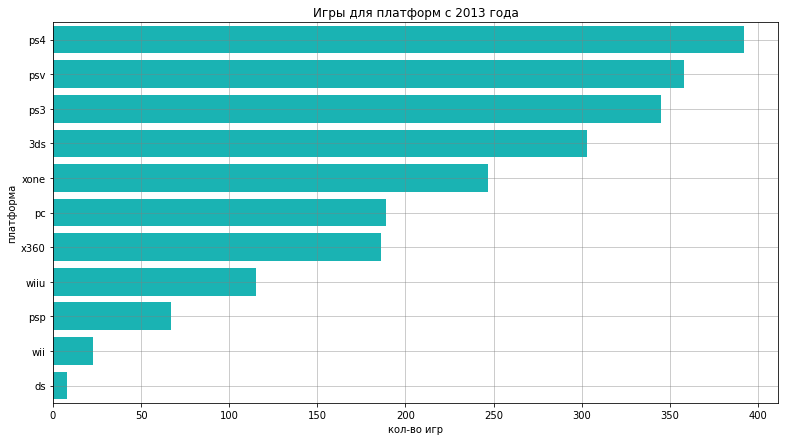

In [76]:
# Настройка размера фигуры
plt.figure(figsize=(13, 7))

# построим гистограмму супер пупер 
sns.barplot(x="name",
            y="platform",
            data=data_current_period.groupby('platform')['name'].count().reset_index().sort_values(by='name', ascending=False),
            color='#00CDCD'
)
# установка заголовка графика
plt.title('Игры для платформ с 2013 года')
# подписи для оси X
plt.xlabel('кол-во игр')
# подписи для оси Y
plt.ylabel('платформа')
# сетка на графике, серого цвета с прозрачностью 0.5
plt.grid(color='grey', axis='both', alpha=0.5)
plt.show()

Самая популярная ps3 c 2009 года

In [77]:
# групировка по платформа
platform_ps3 = data_current_period[data_current_period['platform']=='ps3'].groupby('year_of_release')['sales_total'].sum()
platform_ps3

year_of_release
2013    113.25
2014     47.76
2015     16.82
2016      3.60
Name: sales_total, dtype: float64

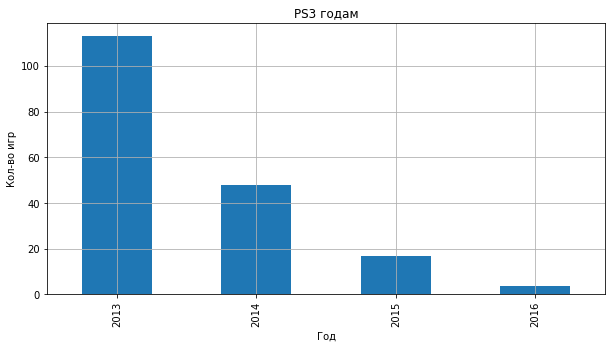

In [78]:
# выведим гистограмму по годам и играми
(
    platform_ps3
    .plot(kind='bar', grid=True, figsize=(10, 5))
)
plt.title('PS3 годам')
plt.xlabel('Год')
plt.ylabel('Кол-во игр')

plt.show()

In [79]:
# групировка по платформа
platform_pc = data_current_period[data_current_period['platform']=='pc'].groupby('year_of_release')['sales_total'].sum()
platform_pc

year_of_release
2013    12.38
2014    13.28
2015     8.52
2016     5.25
Name: sales_total, dtype: float64

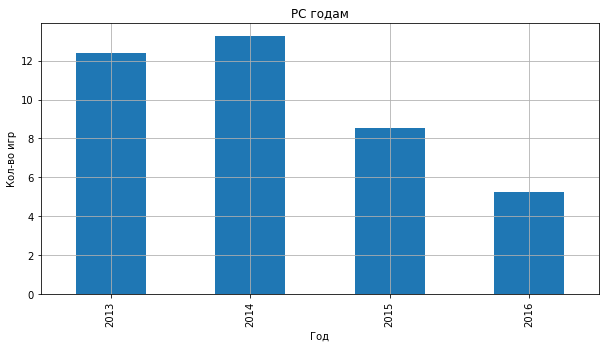

In [80]:
# выведим гистограмму по годам и играми
(
    platform_pc
    .plot(kind='bar', grid=True, figsize=(10, 5))
)
plt.title('PC годам')
plt.xlabel('Год')
plt.ylabel('Кол-во игр')

plt.show()

По всем графикам видно что тренд платформ убывающий. Но у нас данные до 2016 года, была популярна PS3, посмотрим как ps4 на графике

In [81]:
# групировка по платформа
platform_ps4 = data_current_period[data_current_period['platform']=='ps4'].groupby('year_of_release')['sales_total'].sum()
platform_ps4

year_of_release
2013     25.99
2014    100.00
2015    118.90
2016     69.25
Name: sales_total, dtype: float64

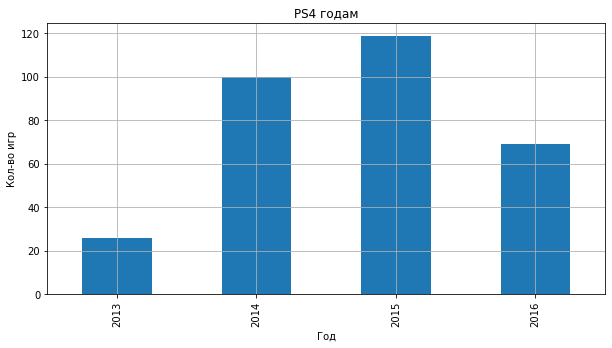

In [82]:
# выведим гистограмму по годам и играми
(
    platform_ps4
    .plot(kind='bar', grid=True, figsize=(10, 5))
)
plt.title('PS4 годам')
plt.xlabel('Год')
plt.ylabel('Кол-во игр')

plt.show()

за 2016 год у нас могут быть не полные данные, но мы значем что ps5 вышла в 2020 году, а средний срок платформы 7 лет. Эта самая перспективная платформа.

In [83]:
# сводна макс и мин годов по платформам
data_term_current_period = data_current_period.pivot_table(index='platform', values='year_of_release', aggfunc=('max','min'))
data_term_current_period

,max,min
platform,,
3ds,2016,2013
ds,2013,2013
pc,2016,2013
ps3,2016,2013
ps4,2016,2013
psp,2015,2013
psv,2016,2013
wii,2016,2013
wiiu,2016,2013


In [84]:
# добавим столбец разницы data_term
data_term_current_period['p_term'] = data_term_current_period['max'] - data_term_current_period['min']
data_term_current_period

,max,min,p_term
platform,,,
3ds,2016,2013,3
ds,2013,2013,0
pc,2016,2013,3
ps3,2016,2013,3
ps4,2016,2013,3
psp,2015,2013,2
psv,2016,2013,3
wii,2016,2013,3
wiiu,2016,2013,3


In [85]:
# отфильтруем таблицу там где равно 2016 году и там где срок не менее 4 лет
data_term_current_period = data_term_current_period.query('max == 2016 and p_term < 4')
data_term_current_period

,max,min,p_term
platform,,,
3ds,2016,2013,3
pc,2016,2013,3
ps3,2016,2013,3
ps4,2016,2013,3
psv,2016,2013,3
wii,2016,2013,3
wiiu,2016,2013,3
x360,2016,2013,3
xone,2016,2013,3


2 самые переспективные игры, по ним срок 3 года, а средний срок существования платформы 8 лет, пик продажаж обычно по середине по ним какараз нет еще 4 лет

#### Постройте график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Опишите результат.

In [86]:
# создадим список платформ которые торгуют в 2016 году
list_trading_platforms_2016 = data.query('year_of_release == 2016')
list_trading_platforms_2016 = list_trading_platforms_2016['platform'].unique()
list_trading_platforms_2016

array(['ps4', '3ds', 'xone', 'wiiu', 'ps3', 'pc', 'x360', 'psv', 'wii'],
      dtype=object)

9 платформ которые есть в 2016 году

In [87]:
# отфильтруем данные по списку
data_current_period_2016 = data_current_period.query('platform in @list_trading_platforms_2016')

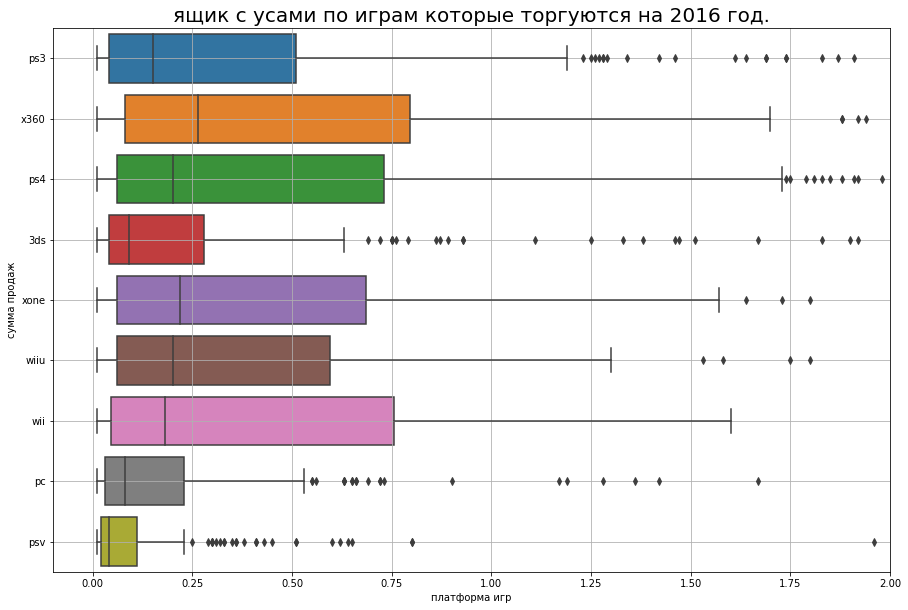

In [88]:
# сформируем ящик с усами только только по играм которые есть в 2016 году
plt.figure(figsize=(15, 10))
plt.xlim(-0.1, 2)
plt.title('ящик с усами по играм которые торгуются на 2016 год.', fontsize=20)
sns.boxplot(x='sales_total', y='platform', data=data_current_period_2016, orient='h')
plt.ylabel('сумма продаж')
plt.xlabel('платформа игр')
plt.grid(True)

plt.show()

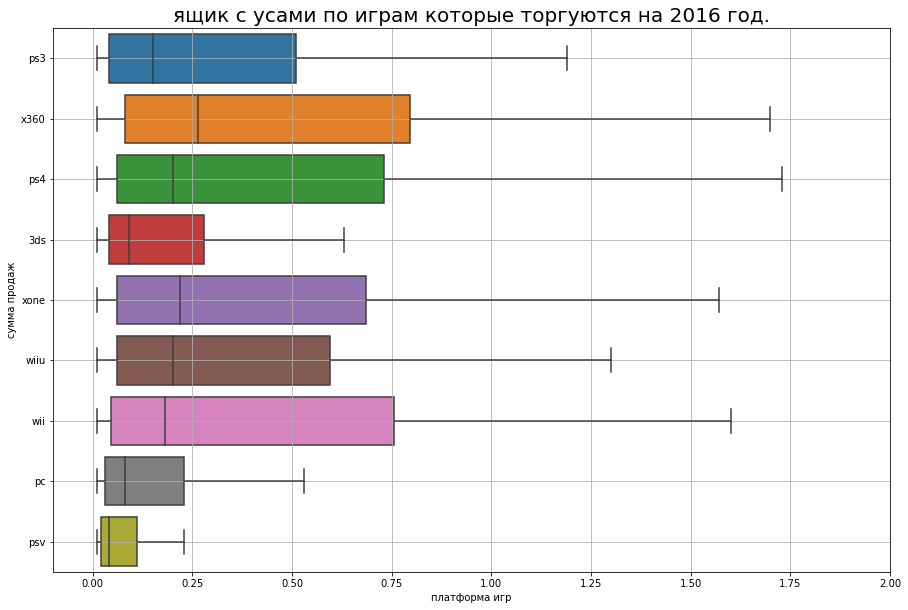

In [89]:
# сформируем ящик с усами только только по играм которые есть в 2016 году , без выбросов
plt.figure(figsize=(15, 10))
plt.xlim(-0.1, 2)
plt.title('ящик с усами по играм которые торгуются на 2016 год.', fontsize=20)
sns.boxplot(x='sales_total', y='platform', data=data_current_period_2016, orient='h', showfliers=False)
plt.ylabel('сумма продаж')
plt.xlabel('платформа игр')
plt.grid(True)

plt.show()

Вывод: 
- на графиках явно выделяются платформы x360, wii, ps4, xone и ps3
- медианные значения у лидеров на много дальше чем у других
- размах усов ящиков ограничен минимуом и максимумом
- в диапазон попадает большенство нормальный значений
- выбросы находятся за пределами усов

#### Посмотрите, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. Постройте диаграмму рассеяния и посчитайте корреляцию между отзывами и продажами. Сформулируйте выводы.

выберим ps4

In [90]:
# создадим датафрейм для платформы ps4
data_ps4 = data.query('platform == "ps4" and user_score != -1 and critic_score != -1')
data_ps4.head(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales_total
42,grand theft auto v,ps4,2014,action,3.96,6.31,0.38,1.97,97,8.3,m,12.62
77,fifa 16,ps4,2015,sports,1.12,6.12,0.06,1.28,82,4.3,e,8.58
92,call of duty: advanced warfare,ps4,2014,shooter,2.81,3.48,0.14,1.23,83,5.7,m,7.66
94,fifa 17,ps4,2016,sports,0.66,5.75,0.08,1.11,85,5.0,e,7.60
105,fallout 4,ps4,2015,role-playing,2.53,3.27,0.24,1.13,87,6.5,m,7.17


In [91]:
# построим сводную корриляцию user
data_ps4['sales_total'].corr(data_ps4['user_score'])

-0.03362497596528878

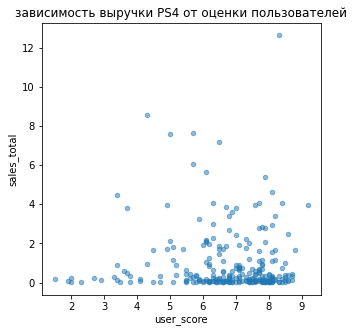

In [92]:
# построим зависимость выручки PS4 от оценки пользователей

(
    data_ps4
    .plot(y='sales_total', x='user_score', kind='scatter', alpha=0.5, figsize=(5, 5))
)
plt.title('зависимость выручки PS4 от оценки пользователей')
plt.show()

слабая зависимость

In [93]:
# построим сводную корриляцию
data_ps4['sales_total'].corr(data_ps4['critic_score'])

0.40589480145836687

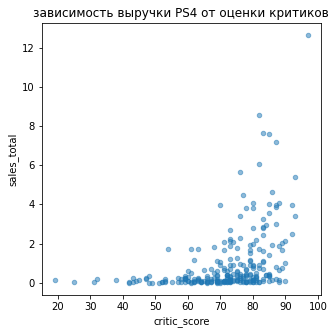

In [94]:
# построим зависимость выручки PS4 от оценки critic

(
    data_ps4
    .plot(y='sales_total', x='critic_score', kind='scatter', alpha=0.5, figsize=(5, 5))
)
plt.title('зависимость выручки PS4 от оценки критиков')
plt.show()

видно что зависимость есть сильнее от оценки критиков

#### Соотнесите выводы с продажами игр на других платформах.

In [95]:
# создадим датафрейм для платформы всех платформ выпускающихся 
# по списку 'ps4', '3ds', 'xone', 'wiiu', 'ps3', 'pc', 'x360', 'psv', 'wii'
data_current_period_2016_filter = data_current_period_2016.query('user_score != -1 and critic_score != -1')
data_current_period_2016_filter

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales_total
16,grand theft auto v,ps3,2013,action,7.02,9.09,0.98,3.96,97,8.2,m,21.05
23,grand theft auto v,x360,2013,action,9.66,5.14,0.06,1.41,97,8.1,m,16.27
42,grand theft auto v,ps4,2014,action,3.96,6.31,0.38,1.97,97,8.3,m,12.62
60,call of duty: ghosts,x360,2013,shooter,6.73,2.56,0.04,0.91,73,2.6,m,10.24
69,call of duty: ghosts,ps3,2013,shooter,4.10,3.63,0.38,1.25,71,2.6,m,9.36
...,...,...,...,...,...,...,...,...,...,...,...,...
16597,saints row: gat out of hell,xone,2015,action,0.00,0.01,0.00,0.00,65,6.0,m,0.01
16630,sébastien loeb rally evo,xone,2016,racing,0.00,0.01,0.00,0.00,63,8.2,e,0.01
16652,fast racing neo,wiiu,2016,action,0.00,0.01,0.00,0.00,81,8.5,e,0.01
16660,prison architect,xone,2016,action,0.01,0.00,0.00,0.00,74,6.7,unknown,0.01


In [96]:
# построим сводную корриляцию user
# по списку 'ps4', '3ds', 'xone', 'wiiu', 'ps3', 'pc', 'x360', 'psv', 'wii'
data_current_period_2016_filter['sales_total'].corr(data_current_period_2016_filter['user_score'])

-0.00364154600139652

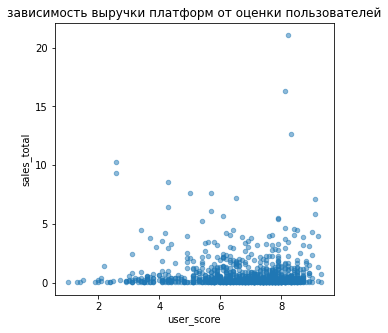

In [97]:
# построим зависимость выручки оценки пользователей
# по списку 'ps4', '3ds', 'xone', 'wiiu', 'ps3', 'pc', 'x360', 'psv', 'wii'

(
    data_current_period_2016_filter
    .plot(y='sales_total', x='user_score', kind='scatter', alpha=0.5, figsize=(5, 5))
)
plt.title('зависимость выручки платформ от оценки пользователей')
plt.show()

In [98]:
# построим сводную корриляцию
# по списку 'ps4', '3ds', 'xone', 'wiiu', 'ps3', 'pc', 'x360', 'psv', 'wii'
data_current_period_2016_filter['sales_total'].corr(data_current_period_2016_filter['critic_score'])

0.3117785271781306

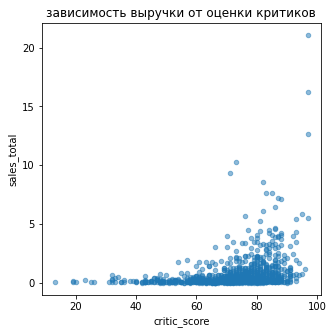

In [99]:
# построим зависимость выручки от оценки critic
# по списку 'ps4', '3ds', 'xone', 'wiiu', 'ps3', 'pc', 'x360', 'psv', 'wii'
(
    data_current_period_2016_filter
    .plot(y='sales_total', x='critic_score', kind='scatter', alpha=0.5, figsize=(5, 5))
)
plt.title('зависимость выручки от оценки критиков')
plt.show()

Выыод, если смотреть все игры то на графиках не видно сильно выраженную разницу, для платформы ps4 она более явная


Так, 2-3 платформы, посмотрим из топ 5, явно выделяются платформы x360, xone

In [100]:
# создадим датафрейм для платформы x360
data_x360 = data_current_period_2016_filter.query('platform == "x360" ')
data_x360.head(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales_total
23,grand theft auto v,x360,2013,action,9.66,5.14,0.06,1.41,97,8.1,m,16.27
60,call of duty: ghosts,x360,2013,shooter,6.73,2.56,0.04,0.91,73,2.6,m,10.24
271,fifa 14,x360,2013,sports,0.92,2.89,0.01,0.40,84,4.2,e,4.22
380,battlefield 4,x360,2013,shooter,2.15,1.01,0.02,0.31,79,5.6,m,3.49
410,assassin's creed iv: black flag,x360,2013,action,1.90,1.11,0.01,0.29,86,7.9,m,3.31


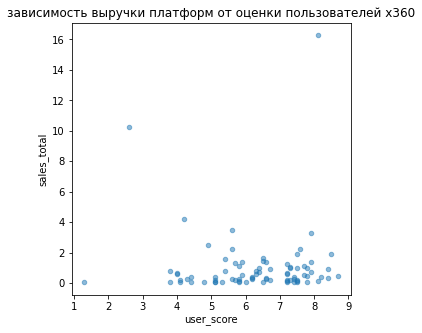

корриляция x360 user равна:  -0.006238179532306317


In [101]:
# построим зависимость выручки оценки пользователей
(
    data_x360
    .plot(y='sales_total', x='user_score', kind='scatter', alpha=0.5, figsize=(5, 5))
)
plt.title('зависимость выручки платформ от оценки пользователей x360')
plt.show()

# построим сводную корриляцию user
print('корриляция x360 user равна: ', data_x360['sales_total'].corr(data_x360['user_score']))

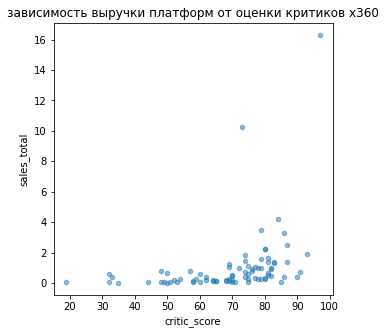

корриляцияx360 critic равна:  0.3503445460228664


In [102]:
# построим зависимость выручки оценки критиков
(
    data_x360
    .plot(y='sales_total', x='critic_score', kind='scatter', alpha=0.5, figsize=(5, 5))
)
plt.title('зависимость выручки платформ от оценки критиков x360')
plt.show()

# построим сводную корриляцию user
print('корриляцияx360 critic равна: ', data_x360['sales_total'].corr(data_x360['critic_score']))

Вывод, по платформе x360 сильнее зависмость от оценки критиков

In [103]:
# создадим датафрейм для платформы xone
data_xone = data_current_period_2016_filter.query('platform == "xone"')
data_xone.head(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales_total
165,grand theft auto v,xone,2014,action,2.81,2.19,0.00,0.47,97,7.9,m,5.47
179,call of duty: advanced warfare,xone,2014,shooter,3.22,1.55,0.01,0.48,81,5.4,m,5.26
242,halo 5: guardians,xone,2015,shooter,2.78,1.27,0.03,0.41,84,6.4,t,4.49
270,fallout 4,xone,2015,role-playing,2.51,1.32,0.01,0.38,88,6.2,m,4.22
373,assassin's creed: unity,xone,2014,action,2.27,0.90,0.00,0.33,72,4.1,m,3.50


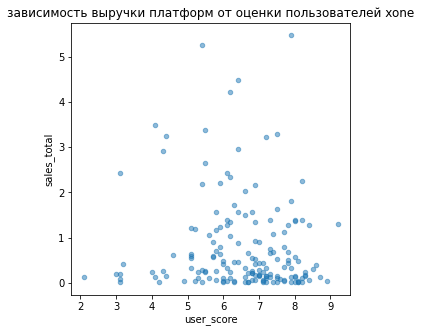

корриляция xone  user равна:  -0.09400318326920852


In [104]:
# построим зависимость выручки оценки пользователей
(
    data_xone
    .plot(y='sales_total', x='user_score', kind='scatter', alpha=0.5, figsize=(5, 5))
)
plt.title('зависимость выручки платформ от оценки пользователей xone')
plt.show()

# построим сводную корриляцию user
print('корриляция xone  user равна: ', data_xone['sales_total'].corr(data_xone['user_score']))

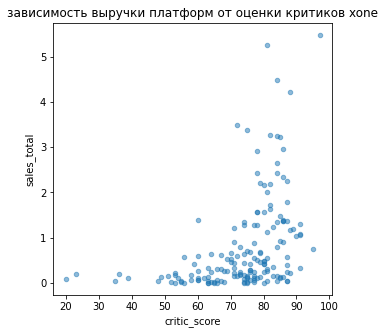

корриляция xone critic равна:  0.4104220356129637


In [105]:
# построим зависимость выручки оценки критиков
(
    data_xone
    .plot(y='sales_total', x='critic_score', kind='scatter', alpha=0.5, figsize=(5, 5))
)
plt.title('зависимость выручки платформ от оценки критиков xone')
plt.show()

# построим сводную корриляцию user
print('корриляция xone critic равна: ', data_xone['sales_total'].corr(data_xone['critic_score']))

Вывод, по платформе xone сильнее зависмость от оценки критиков

Вывод: По большенству платформ видно зависимость от оценков критиков

#### Посмотрите на общее распределение игр по жанрам. Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?

In [106]:
# свод по жанрам сумма
pivot_genre = data_current_period.pivot_table(
    index='genre',
    values='sales_total',
    aggfunc=('sum','mean','median', 'count')
)
pivot_genre

,count,mean,median,sum
genre,,,,
action,766,0.420196,0.110,321.87
adventure,245,0.096490,0.030,23.64
fighting,80,0.441375,0.125,35.31
misc,155,0.405290,0.100,62.82
platform,74,0.576081,0.225,42.63
puzzle,17,0.186471,0.060,3.17
racing,85,0.469294,0.120,39.89
role-playing,292,0.499623,0.125,145.89
shooter,187,1.245882,0.450,232.98


In [107]:
# добавим столбец доля
pivot_genre['fraction_count'] = (pivot_genre['count'] / pivot_genre['count'].sum()).map('{:.1%}'.format)
pivot_genre

,count,mean,median,sum,fraction_count
genre,,,,,
action,766,0.420196,0.110,321.87,34.3%
adventure,245,0.096490,0.030,23.64,11.0%
fighting,80,0.441375,0.125,35.31,3.6%
misc,155,0.405290,0.100,62.82,6.9%
platform,74,0.576081,0.225,42.63,3.3%
puzzle,17,0.186471,0.060,3.17,0.8%
racing,85,0.469294,0.120,39.89,3.8%
role-playing,292,0.499623,0.125,145.89,13.1%
shooter,187,1.245882,0.450,232.98,8.4%


In [108]:
# выведим топ жанров по доле игр на рынке
pivot_genre.sort_values(by='sum', ascending=False).head(5)

,count,mean,median,sum,fraction_count
genre,,,,,
action,766,0.420196,0.110,321.87,34.3%
shooter,187,1.245882,0.450,232.98,8.4%
sports,214,0.703972,0.240,150.65,9.6%
role-playing,292,0.499623,0.125,145.89,13.1%
misc,155,0.405290,0.100,62.82,6.9%


In [109]:
# выведим топ жанров по сумме продаж
pivot_genre.sort_values(by='count', ascending=False).head(5)

,count,mean,median,sum,fraction_count
genre,,,,,
action,766,0.420196,0.110,321.87,34.3%
role-playing,292,0.499623,0.125,145.89,13.1%
adventure,245,0.096490,0.030,23.64,11.0%
sports,214,0.703972,0.240,150.65,9.6%
shooter,187,1.245882,0.450,232.98,8.4%


In [110]:
# выведим топ жанров по среднену значению
pivot_genre.sort_values(by='mean', ascending=False).head(5)

,count,mean,median,sum,fraction_count
genre,,,,,
shooter,187,1.245882,0.450,232.98,8.4%
sports,214,0.703972,0.240,150.65,9.6%
platform,74,0.576081,0.225,42.63,3.3%
role-playing,292,0.499623,0.125,145.89,13.1%
racing,85,0.469294,0.120,39.89,3.8%


In [111]:
# выведим топ жанров по медианному значению
pivot_genre.sort_values(by='median', ascending=False).head(5)

,count,mean,median,sum,fraction_count
genre,,,,,
shooter,187,1.245882,0.450,232.98,8.4%
sports,214,0.703972,0.240,150.65,9.6%
platform,74,0.576081,0.225,42.63,3.3%
role-playing,292,0.499623,0.125,145.89,13.1%
fighting,80,0.441375,0.125,35.31,3.6%


Вывод:
- если расматривать долю игр на рынке, то самый большой 34.3% игр в жанре action
- если расматривать среднее значение, то лидирует жанр игр shooter
- если расматривать медианное значение, то лидирует так же shooter


Построим график, супер пупер давали на консульация, сейчас применим

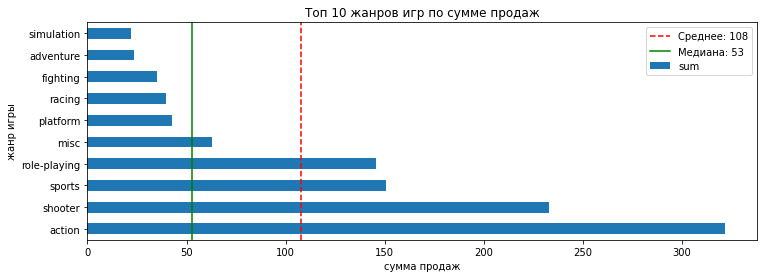

In [112]:
# Топ 10 жанров игр по сумме
top_genre = pivot_genre.sort_values(
    by="sum", ascending=False
).head(10)
top_genre["sum"].plot(kind="barh", figsize=(12, 4))
plt.title("Топ 10 жанров игр по сумме продаж")
plt.xlabel("сумма продаж")
plt.ylabel("жанр игры")
mean_sum = top_genre["sum"].mean()
median_sum = top_genre["sum"].median()
plt.axvline(mean_sum, color="r", linestyle="--", label=f"Среднее: {mean_sum:.0f}")
plt.axvline(
    median_sum, color="g", linestyle="-", label=f"Медиана: {median_sum:.0f}"
)
plt.legend()
plt.show()

вывод по графику:
- по сумме продаж по медианному значению ярко выражены 5 жанров игр
- по сумме продаж по среднему значению ярко выражены 4 жанра игр

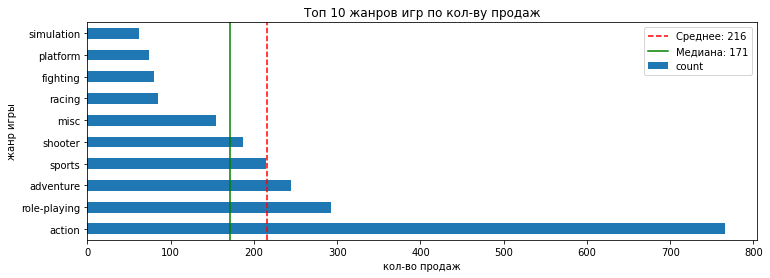

In [113]:
# Топ 10 жанров игр по кол-ву
top_genre = pivot_genre.sort_values(
    by="count", ascending=False
).head(10)
top_genre["count"].plot(kind="barh", figsize=(12, 4))
plt.title("Топ 10 жанров игр по кол-ву продаж")
plt.xlabel("кол-во продаж")
plt.ylabel("жанр игры")
mean_count = top_genre["count"].mean()
median_count = top_genre["count"].median()
plt.axvline(mean_count, color="r", linestyle="--", label=f"Среднее: {mean_count:.0f}")
plt.axvline(
    median_count, color="g", linestyle="-", label=f"Медиана: {median_count:.0f}"
)
plt.legend()
plt.show()

вывод по графику:
- по сумме продаж по медианному значению ярко выражены 5 жанров игр
- по сумме продаж по среднему значению ярко выражены 3 жанра игр

<div class="alert alert-block alert-info">
<b>🔄Комментарий студента:</b> 
вот так получилось
</div>

#### Вывод иследовательского анализа данных
- Игры выпускаются с 1980 года по 2016 год, максимальное количество игр выпускалось в 2008 году 1427 шт.
- Средний срок жизни платформы 7-8 лет
- Период для обработки мы взяли с 2009 по 2016 год
- Самые перспективные 2 платформы PS4 и Xone
- По графику с усами видно что в топе платформ выделяются x360, ps3, ps4 и xone
- Взяли для анализа игру PS4 , оценка критиков больше влияет на продаваемость чем оценки прользователей
- Самый популярный жанр игр action
	

### Шаг 4. Составьте портрет пользователя каждого региона

Возьмем данные с 2013 года только актуальные приставки на 2016 год

In [114]:
data_current_period_2016.head(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales_total
16,grand theft auto v,ps3,2013,action,7.02,9.09,0.98,3.96,97,8.2,m,21.05
23,grand theft auto v,x360,2013,action,9.66,5.14,0.06,1.41,97,8.1,m,16.27
31,call of duty: black ops 3,ps4,2015,shooter,6.03,5.86,0.36,2.38,-1,-1.0,unknown,14.63
33,pokemon x/pokemon y,3ds,2013,role-playing,5.28,4.19,4.35,0.78,-1,-1.0,unknown,14.60
42,grand theft auto v,ps4,2014,action,3.96,6.31,0.38,1.97,97,8.3,m,12.62


Определите для пользователя каждого региона (NA, EU, JP):
- NA_sales — продажи в Северной Америке (миллионы проданных копий)
- EU_sales — продажи в Европе (миллионы проданных копий)
- JP_sales — продажи в Японии (миллионы проданных копий)
 - Самые популярные платформы (топ-5). Опишите различия в долях продаж.
 - Самые популярные жанры (топ-5). Поясните разницу.
 - Влияет ли рейтинг ESRB на продажи в отдельном регионе?

#### NA_sales — продажи в Северной Америке (миллионы проданных копий)

NA - Самые популярные платформы (топ-5). Опишите различия в долях продаж.

In [115]:
# свод по платформам
na_sales_p_top = data_current_period_2016.pivot_table(
    index='platform', values='na_sales', aggfunc='sum').sort_values(
    by='na_sales', ascending=False)
# добавим долю
na_sales_p_top['fraction'] = (na_sales_p_top['na_sales'] / na_sales_p_top['na_sales'].sum()).map('{:.1%}'.format)
# сохраним 5 платформ
na_sales_p_top = na_sales_p_top.head(5)
# выведим на экран
na_sales_p_top

,na_sales,fraction
platform,,
ps4,108.74,24.9%
xone,93.12,21.3%
x360,81.66,18.7%
ps3,63.50,14.5%
3ds,38.20,8.7%


NA - Самые популярные жанры (топ-5). Поясните разницу.

In [116]:
# свод по жанрам
na_sales_g_top = data_current_period_2016.pivot_table(
    index='genre', values='na_sales', aggfunc='sum').sort_values(
    by='na_sales', ascending=False)
# добавим долю
na_sales_g_top['fraction'] = (na_sales_g_top['na_sales'] / na_sales_g_top['na_sales'].sum()).map('{:.1%}'.format)
# сохраним топ5
na_sales_g_top = na_sales_g_top.head(5)
# выведим на экран
na_sales_g_top

,na_sales,fraction
genre,,
action,125.83,28.8%
shooter,109.74,25.1%
sports,65.27,14.9%
role-playing,46.40,10.6%
misc,27.46,6.3%


NA - Влияет ли рейтинг ESRB на продажи в отдельном регионе?

In [117]:
# свод по рейтингу
na_sales_r_top = data_current_period_2016.pivot_table(
    index='rating', values='na_sales', aggfunc='sum').sort_values(
    by='na_sales', ascending=False)
# добавим долю
na_sales_r_top['fraction'] = (na_sales_r_top['na_sales'] / na_sales_r_top['na_sales'].sum()).map('{:.1%}'.format)
# сохраним топ 5
na_sales_r_top = na_sales_r_top.head(5)
# выведим на экран
na_sales_r_top

,na_sales,fraction
rating,,
m,165.21,37.8%
unknown,89.18,20.4%
e,78.94,18.1%
e10+,54.02,12.4%
t,49.79,11.4%


In [118]:
# свод по рейтингу без unknown
na_sales_r_top = data_current_period_2016.query('rating != "unknown"').pivot_table(
    index='rating', values='na_sales', aggfunc='sum').sort_values(
    by='na_sales', ascending=False)
# добавим долю
na_sales_r_top['fraction'] = (na_sales_r_top['na_sales'] / na_sales_r_top['na_sales'].sum()).map('{:.1%}'.format)
# сохраним топ 5
na_sales_r_top = na_sales_r_top.head(5)
# выведим на экран
na_sales_r_top

,na_sales,fraction
rating,,
m,165.21,47.5%
e,78.94,22.7%
e10+,54.02,15.5%
t,49.79,14.3%


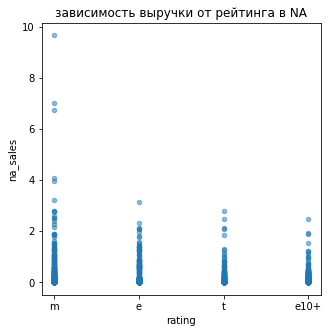

In [119]:
# построим зависимость выручки от оценки reting

(
    data_current_period_2016.query('rating != "unknown"')
    .plot(y='na_sales', x='rating', kind='scatter', alpha=0.5, figsize=(5, 5))
)
plt.title('зависимость выручки от рейтинга в NA')
plt.show()

#### Вывод NA:
 - Самые популярные платформы (топ-5). Опишите различия в долях продаж.
  - ps4	xone	x360	ps3	3ds

 - Самые популярные жанры (топ-5). Поясните разницу.
  - action	shooter	sports	role-playing	misc

 - Влияет ли рейтинг ESRB на продажи в отдельном регионе?
  - есть зависимость

#### EU_sales — продажи в Европе (миллионы проданных копий)

EU - Самые популярные платформы (топ-5). Опишите различия в долях продаж.


In [120]:
# свод по платформам
eu_sales_p_top = data_current_period_2016.pivot_table(
    index='platform', values='eu_sales', aggfunc='sum').sort_values(
    by='eu_sales', ascending=False)
# добавим долю
eu_sales_p_top['fraction'] = (eu_sales_p_top['eu_sales'] / eu_sales_p_top['eu_sales'].sum()).map('{:.1%}'.format)
# сохраним 5 платформ
eu_sales_p_top = eu_sales_p_top.head(5)
# выведим на экран
eu_sales_p_top

,eu_sales,fraction
platform,,
ps4,141.09,36.1%
ps3,67.81,17.3%
xone,51.59,13.2%
x360,42.52,10.9%
3ds,30.96,7.9%


EU - Самые популярные жанры (топ-5). Поясните разницу.


In [121]:
# свод по жанрам
eu_sales_g_top = data_current_period_2016.pivot_table(
    index='genre', values='eu_sales', aggfunc='sum').sort_values(
    by='eu_sales', ascending=False)
# добавим долю
eu_sales_g_top['fraction'] = (eu_sales_g_top['eu_sales'] / eu_sales_g_top['eu_sales'].sum()).map('{:.1%}'.format)
# сохраним топ5
eu_sales_g_top = eu_sales_g_top.head(5)
# выведим на экран
eu_sales_g_top

,eu_sales,fraction
genre,,
action,117.87,30.1%
shooter,87.86,22.5%
sports,60.34,15.4%
role-playing,36.97,9.5%
racing,20.19,5.2%


EU - Влияет ли рейтинг ESRB на продажи в отдельном регионе?

In [122]:
# свод по рейтингу
eu_sales_r_top = data_current_period_2016.pivot_table(
    index='rating', values='eu_sales', aggfunc='sum').sort_values(
    by='eu_sales', ascending=False)
# добавим долю
eu_sales_r_top['fraction'] = (eu_sales_r_top['eu_sales'] / eu_sales_r_top['eu_sales'].sum()).map('{:.1%}'.format)
# сохраним топ 5
eu_sales_r_top = eu_sales_r_top.head(5)
# выведим на экран
eu_sales_r_top

,eu_sales,fraction
rating,,
m,145.32,37.1%
e,82.80,21.2%
unknown,78.61,20.1%
e10+,42.53,10.9%
t,41.95,10.7%


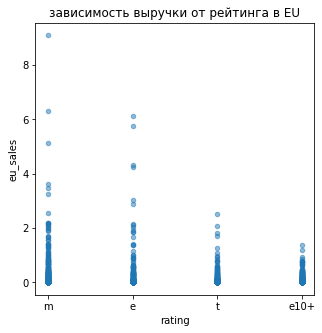

In [123]:
# построим зависимость выручки от оценки reting

(
    data_current_period_2016.query('rating != "unknown"')
    .plot(y='eu_sales', x='rating', kind='scatter', alpha=0.5, figsize=(5, 5))
)
plt.title('зависимость выручки от рейтинга в EU')
plt.show()

#### Вывод EU:
 - Самые популярные платформы (топ-5). Опишите различия в долях продаж.
  - ps4	ps3	xone x360 3ds
  
 - Самые популярные жанры (топ-5). Поясните разницу.
  -  action	shooter	sports	role-playing	racing

 - Влияет ли рейтинг ESRB на продажи в отдельном регионе?
  - есть зависимость

#### JP_sales — продажи в Японии (миллионы проданных копий)

JP - Самые популярные платформы (топ-5). Опишите различия в долях продаж.


In [124]:
# свод по платформам
jp_sales_p_top = data_current_period_2016.pivot_table(
    index='platform', values='jp_sales', aggfunc='sum').sort_values(
    by='jp_sales', ascending=False)
# добавим долю
jp_sales_p_top['fraction'] = (jp_sales_p_top['jp_sales'] / jp_sales_p_top['jp_sales'].sum()).map('{:.1%}'.format)
# сохраним 5 платформ
jp_sales_p_top = jp_sales_p_top.head(5)
# выведим на экран
jp_sales_p_top

,jp_sales,fraction
platform,,
3ds,67.81,49.3%
ps3,23.35,17.0%
psv,18.59,13.5%
ps4,15.96,11.6%
wiiu,10.88,7.9%


JP - Самые популярные жанры (топ-5). Поясните разницу.


In [125]:
# свод по жанрам
jp_sales_g_top = data_current_period_2016.pivot_table(
    index='genre', values='jp_sales', aggfunc='sum').sort_values(
    by='jp_sales', ascending=False)
# добавим долю
jp_sales_g_top['fraction'] = (jp_sales_g_top['jp_sales'] / jp_sales_g_top['jp_sales'].sum()).map('{:.1%}'.format)
# сохраним топ5
jp_sales_g_top = jp_sales_g_top.head(5)
# выведим на экран
jp_sales_g_top

,jp_sales,fraction
genre,,
role-playing,50.01,36.4%
action,39.65,28.8%
misc,9.03,6.6%
fighting,7.63,5.5%
shooter,6.61,4.8%


JP - Влияет ли рейтинг ESRB на продажи в отдельном регионе?

In [126]:
# свод по рейтингу
jp_sales_r_top = data_current_period_2016.pivot_table(
    index='rating', values='jp_sales', aggfunc='sum').sort_values(
    by='jp_sales', ascending=False)
# добавим долю
jp_sales_r_top['fraction'] = (jp_sales_r_top['jp_sales'] / jp_sales_r_top['jp_sales'].sum()).map('{:.1%}'.format)
# сохраним топ 5
jp_sales_r_top = jp_sales_r_top.head(5)
# выведим на экран
jp_sales_r_top

,jp_sales,fraction
rating,,
unknown,82.05,59.7%
t,20.44,14.9%
e,15.00,10.9%
m,14.11,10.3%
e10+,5.89,4.3%


In [127]:
# свод по рейтингу без unknown
jp_sales_r_top = data_current_period_2016.query('rating != "unknown"').pivot_table(
    index='rating', values='jp_sales', aggfunc='sum').sort_values(
    by='jp_sales', ascending=False)
# добавим долю
jp_sales_r_top['fraction'] = (jp_sales_r_top['jp_sales'] / jp_sales_r_top['jp_sales'].sum()).map('{:.1%}'.format)
# сохраним топ 5
jp_sales_r_top = jp_sales_r_top.head(5)
# выведим на экран
jp_sales_r_top

,jp_sales,fraction
rating,,
t,20.44,36.9%
e,15.00,27.1%
m,14.11,25.5%
e10+,5.89,10.6%


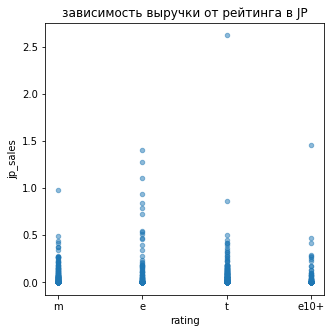

In [128]:
# построим зависимость выручки от оценки reting

(
    data_current_period_2016.query('rating != "unknown"')
    .plot(y='jp_sales', x='rating', kind='scatter', alpha=0.5, figsize=(5, 5))
)
plt.title('зависимость выручки от рейтинга в JP')
plt.show()

#### Вывод JP:
 - Самые популярные платформы (топ-5). Опишите различия в долях продаж.
  - 3ds	ps3	psv	ps4	wiiu

 - Самые популярные жанры (топ-5). Поясните разницу.
  -  role-playing	action	misc	fighting	shooter

 - Влияет ли рейтинг ESRB на продажи в отдельном регионе?
  - есть зависимость

#### other_sales другие страны

other - Самые популярные платформы (топ-5). Опишите различия в долях продаж.


In [129]:
# свод по платформам
other_sales_p_top = data_current_period_2016.pivot_table(
    index='platform', values='other_sales', aggfunc='sum').sort_values(
    by='other_sales', ascending=False)
# добавим долю
other_sales_p_top['fraction'] = (other_sales_p_top['other_sales'] / other_sales_p_top['other_sales'].sum()).map('{:.1%}'.format)
# сохраним 5 платформ
other_sales_p_top = other_sales_p_top.head(5)
# выведим на экран
other_sales_p_top

,other_sales,fraction
platform,,
ps4,48.35,40.4%
ps3,26.77,22.3%
xone,14.27,11.9%
x360,12.11,10.1%
3ds,6.28,5.2%


other - Самые популярные жанры (топ-5). Поясните разницу.


In [130]:
# свод по жанрам
other_sales_g_top = data_current_period_2016.pivot_table(
    index='genre', values='other_sales', aggfunc='sum').sort_values(
    by='other_sales', ascending=False)
# добавим долю
other_sales_g_top['fraction'] = (other_sales_g_top['other_sales'] / other_sales_g_top['other_sales'].sum()).map('{:.1%}'.format)
# сохраним топ5
other_sales_g_top = other_sales_g_top.head(5)
# выведим на экран
other_sales_g_top

,other_sales,fraction
genre,,
action,37.16,31.0%
shooter,28.77,24.0%
sports,19.41,16.2%
role-playing,11.48,9.6%
misc,6.08,5.1%


other - Влияет ли рейтинг ESRB на продажи в отдельном регионе?

In [131]:
# свод по рейтингу
other_sales_r_top = data_current_period_2016.pivot_table(
    index='rating', values='other_sales', aggfunc='sum').sort_values(
    by='other_sales', ascending=False)
other_sales_r_top
# добавим долю
other_sales_r_top['fraction'] = (other_sales_r_top['other_sales'] / other_sales_r_top['other_sales'].sum()).map('{:.1%}'.format)
# сохраним топ 5
other_sales_r_top = other_sales_r_top.head(5)
# выведим на экран
other_sales_r_top

,other_sales,fraction
rating,,
m,47.04,39.3%
unknown,23.41,19.5%
e,22.53,18.8%
t,14.29,11.9%
e10+,12.54,10.5%


In [132]:
# свод по рейтингу без unknown
other_sales_r_top = data_current_period_2016.query('rating != "unknown"').pivot_table(
    index='rating', values='other_sales', aggfunc='sum').sort_values(
    by='other_sales', ascending=False)
other_sales_r_top
# добавим долю
other_sales_r_top['fraction'] = (other_sales_r_top['other_sales'] / other_sales_r_top['other_sales'].sum()).map('{:.1%}'.format)
# сохраним топ 5
other_sales_r_top = other_sales_r_top.head(5)
# выведим на экран
other_sales_r_top

,other_sales,fraction
rating,,
m,47.04,48.8%
e,22.53,23.4%
t,14.29,14.8%
e10+,12.54,13.0%


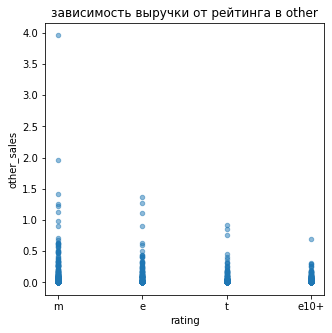

In [133]:
# построим зависимость выручки от оценки reting

(
    data_current_period_2016.query('rating != "unknown"')
    .plot(y='other_sales', x='rating', kind='scatter', alpha=0.5, figsize=(5, 5))
)
plt.title('зависимость выручки от рейтинга в other')
plt.show()

#### Вывод other:
 - Самые популярные платформы (топ-5). Опишите различия в долях продаж.
  - ps4	ps3	xone	x360	3ds

 - Самые популярные жанры (топ-5). Поясните разницу.
  -  action	shooter	sports	role-playing	misc

 - Влияет ли рейтинг ESRB на продажи в отдельном регионе?
  - есть зависимость

<div class="alert alert-block alert-info">
<b>🔄Комментарий студента:</b> 
Поменяла датафрейм на тот что с платформами действующие на 2016 год
</div>

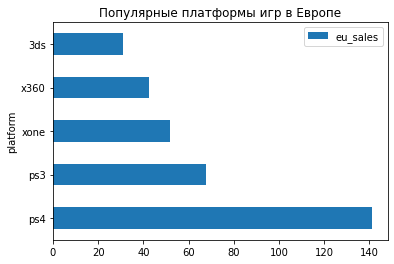

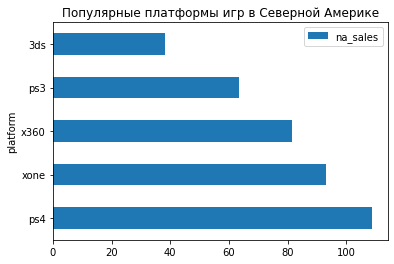

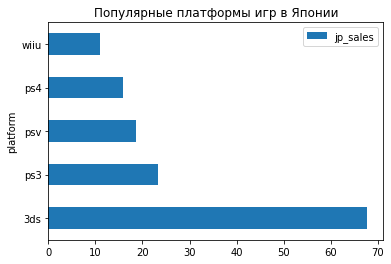

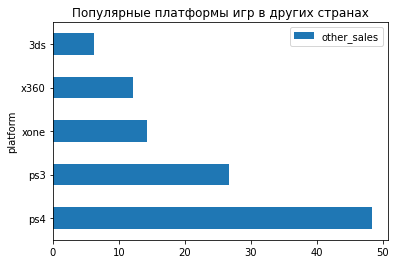

In [134]:
# выведим грфики популярные платформы :
data_current_period_2016.groupby(by='platform').agg({'eu_sales':'sum'}).sort_values(by='eu_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные платформы игр в Европе')
plt.show()
data_current_period_2016.groupby(by='platform').agg({'na_sales':'sum'}).sort_values(by='na_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные платформы игр в Северной Америке')
plt.show()
data_current_period_2016.groupby(by='platform').agg({'jp_sales':'sum'}).sort_values(by='jp_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные платформы игр в Японии')
plt.show()
data_current_period_2016.groupby(by='platform').agg({'other_sales':'sum'}).sort_values(by='other_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные платформы игр в других странах')
plt.show()

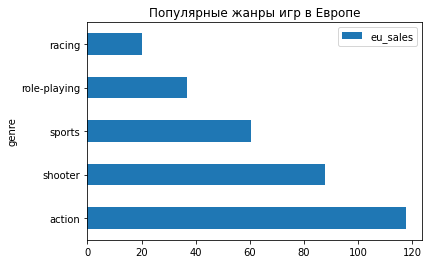

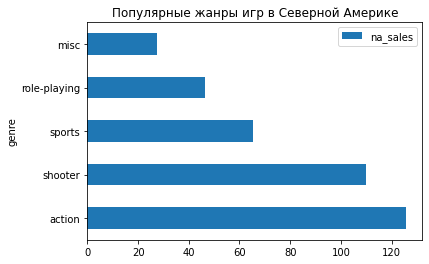

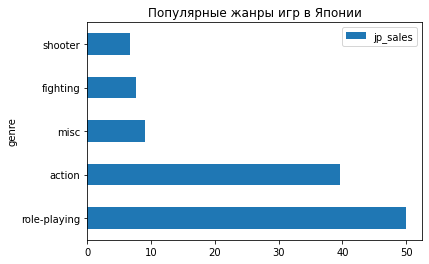

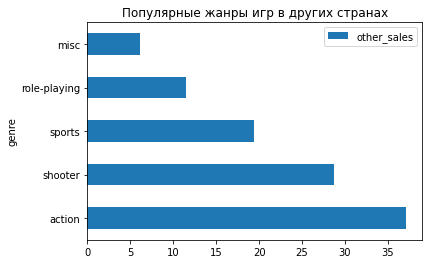

In [135]:
# выведим грфики популярные жанры игр :
data_current_period_2016.groupby(by='genre').agg({'eu_sales':'sum'}).sort_values(by='eu_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные жанры игр в Европе')
plt.show()
data_current_period_2016.groupby(by='genre').agg({'na_sales':'sum'}).sort_values(by='na_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные жанры игр в Северной Америке')
plt.show()
data_current_period_2016.groupby(by='genre').agg({'jp_sales':'sum'}).sort_values(by='jp_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные жанры игр в Японии')
plt.show()
data_current_period_2016.groupby(by='genre').agg({'other_sales':'sum'}).sort_values(by='other_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные жанры игр в других странах')
plt.show()

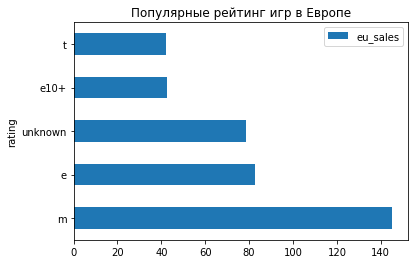

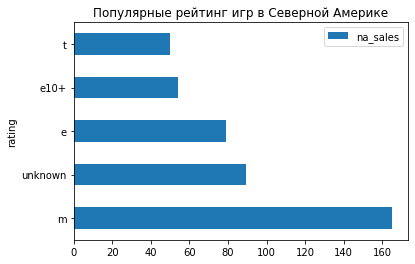

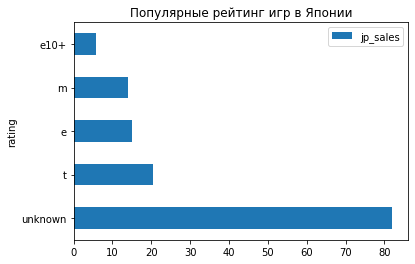

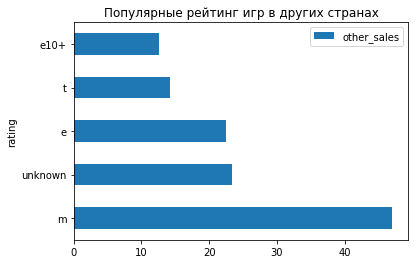

In [136]:
# выведим грфики популярные платформы :
data_current_period_2016.groupby(by='rating').agg({'eu_sales':'sum'}).sort_values(by='eu_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные рейтинг игр в Европе')
plt.show()
data_current_period_2016.groupby(by='rating').agg({'na_sales':'sum'}).sort_values(by='na_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные рейтинг игр в Северной Америке')
plt.show()
data_current_period_2016.groupby(by='rating').agg({'jp_sales':'sum'}).sort_values(by='jp_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные рейтинг игр в Японии')
plt.show()
data_current_period_2016.groupby(by='rating').agg({'other_sales':'sum'}).sort_values(by='other_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные рейтинг игр в других странах')
plt.show()

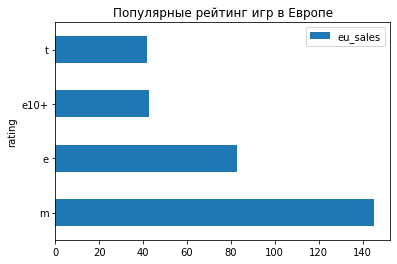

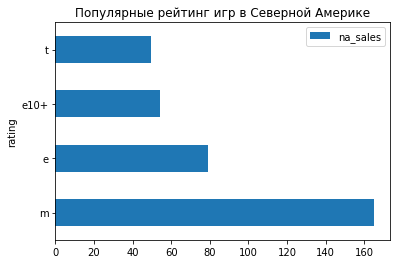

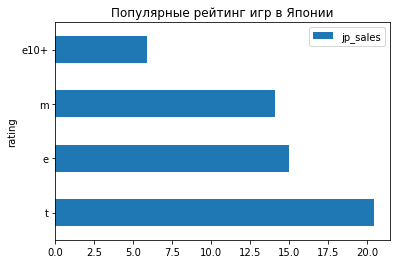

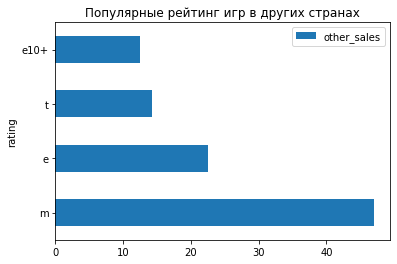

In [137]:
# выведим грфики популярные рейтинг без unknown:
data_current_period_2016.query('rating != "unknown"').groupby(by='rating').agg({'eu_sales':'sum'}).sort_values(by='eu_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные рейтинг игр в Европе')
plt.show()
data_current_period_2016.query('rating != "unknown"').groupby(by='rating').agg({'na_sales':'sum'}).sort_values(by='na_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные рейтинг игр в Северной Америке')
plt.show()
data_current_period_2016.query('rating != "unknown"').groupby(by='rating').agg({'jp_sales':'sum'}).sort_values(by='jp_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные рейтинг игр в Японии')
plt.show()
data_current_period_2016.query('rating != "unknown"').groupby(by='rating').agg({'other_sales':'sum'}).sort_values(by='other_sales', ascending=False).head(5).plot(kind='barh')
plt.title('Популярные рейтинг игр в других странах')
plt.show()

### Шаг 5. Проверьте гипотезы
 - Средние пользовательские рейтинги платформ Xbox One и PC одинаковые;
 - Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.
- Задайте самостоятельно пороговое значение alpha.
- Поясните:
 - Как вы сформулировали нулевую и альтернативную гипотезы;
 - Какой критерий применили для проверки гипотез и почему.

In [138]:
# Задайте самостоятельно пороговое значение alpha.
alpha = .05


#### Средние пользовательские рейтинги платформ Xbox One и PC одинаковые;

- H0 - средние пользовательские рейтинги платформ Xbox One и PC равны
- H1 - средние пользовательские рейтинги платформ Xbox One и PC не равны

In [139]:
# отфильтруем данные
data_current_period_f_user = data_current_period.query('user_score != -1')
data_current_period_f_user

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales_total
16,grand theft auto v,ps3,2013,action,7.02,9.09,0.98,3.96,97,8.2,m,21.05
23,grand theft auto v,x360,2013,action,9.66,5.14,0.06,1.41,97,8.1,m,16.27
42,grand theft auto v,ps4,2014,action,3.96,6.31,0.38,1.97,97,8.3,m,12.62
60,call of duty: ghosts,x360,2013,shooter,6.73,2.56,0.04,0.91,73,2.6,m,10.24
69,call of duty: ghosts,ps3,2013,shooter,4.10,3.63,0.38,1.25,71,2.6,m,9.36
...,...,...,...,...,...,...,...,...,...,...,...,...
16643,rugby challenge 3,xone,2016,sports,0.00,0.01,0.00,0.00,-1,6.6,e,0.01
16652,fast racing neo,wiiu,2016,action,0.00,0.01,0.00,0.00,81,8.5,e,0.01
16654,ben 10 omniverse 2,x360,2013,action,0.00,0.01,0.00,0.00,-1,5.1,e10+,0.01
16660,prison architect,xone,2016,action,0.01,0.00,0.00,0.00,74,6.7,unknown,0.01


In [140]:
data_current_period_f_user['user_score'].unique()

array([8.2, 8.1, 8.3, 2.6, 4.3, 5.7, 5. , 6.5, 9.1, 6.1, 7.9, 5.4, 8.4,
       6.4, 3.4, 8.5, 4.8, 9. , 4.9, 4.5, 6.2, 4.2, 6.3, 7.7, 9.2, 7.6,
       8.7, 6.7, 3.7, 7. , 6.9, 4.1, 5.8, 5.6, 6.8, 5.5, 7.5, 4.4, 5.9,
       7.2, 8.9, 3.9, 7.8, 3.2, 8.6, 3.1, 7.4, 7.3, 6.6, 6. , 4.7, 7.1,
       8.8, 5.1, 3. , 2.9, 2.7, 2.2, 8. , 3.5, 5.2, 5.3, 3.8, 4.6, 3.3,
       9.3, 4. , 3.6, 2.4, 2.8, 1.8, 1.7, 1.6, 2.1, 2. , 1.5, 0.7, 2.5,
       0.2, 1.9, 1.3, 1. , 1.4, 2.3])

In [141]:
# отфильтруем датафреймы по нужным платформам
xone = data_current_period_f_user.query('platform == "xone"')
pc = data_current_period_f_user.query('platform == "pc"')

In [142]:
# зададим
xone_u = xone['user_score']
pc_u = pc['user_score']

In [143]:
# среднее
xone_u.mean()

6.521428571428572

In [144]:
# среднее
pc_u.mean()

6.2696774193548395

Параметр alternative:

 - ‘two-sided’ (по умолчанию, двусторонний): Проверяет, отличаются ли средние значения двух выборок (независимо от направления). Используется для двусторонней гипотезы.
 - ‘less’ (односторонний тест): Проверяет, меньше ли среднее значение первой выборки по сравнению со второй.
 - ‘greater’ (односторонний тест): Проверяет, больше ли среднее значение первой выборки по сравнению со второй.

In [145]:
# выполнение t-теста для сравнения средних значений двух независимых групп
t_stat, p_value = st.ttest_ind(xone_u, pc_u, alternative='two-sided')

print('p-value', p_value)

# оценка результатов
if p_value < 0.05:
    print("Отвергаем нулевую гипотезу: средние пользовательские рейтинги платформ Xbox One и PC не равны")
else:
    print("Не отвергаем нулевую гипотезу: недостаточно доказательств, средние пользовательские рейтинги платформ Xbox One и PC равны")

print(f'Среднее оценка пользователей по платформе XONE: {np.mean(xone_u):.2f}')
print(f'Среднее оценка пользователей по платформе PC: {np.mean(pc_u):.2f}')

p-value 0.14012658403611647
Не отвергаем нулевую гипотезу: недостаточно доказательств, средние пользовательские рейтинги платформ Xbox One и PC равны
Среднее оценка пользователей по платформе XONE: 6.52
Среднее оценка пользователей по платформе PC: 6.27


In [146]:
# выполнение t-теста для сравнения средних значений двух независимых групп
t_stat, p_value = st.ttest_ind(xone_u, pc_u, alternative='two-sided')

print('p-value', p_value)
print('t_stat', t_stat)

p_value_one_sided = p_value / 2
# оценка результатов
if t_stat > 0 and p_value_one_sided < 0.05:
    print("Отвергаем нулевую гипотезу: средние пользовательские рейтинги платформ Xbox One и PC не равны")
else:
    print("Не отвергаем нулевую гипотезу: недостаточно доказательств, средние пользовательские рейтинги платформ Xbox One и PC равны")

p-value 0.14012658403611647
t_stat 1.4788255981357277
Не отвергаем нулевую гипотезу: недостаточно доказательств, средние пользовательские рейтинги платформ Xbox One и PC равны


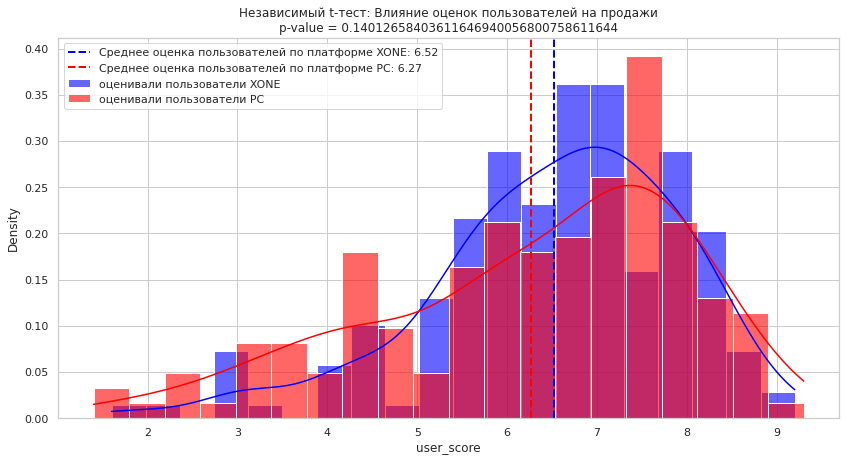

In [147]:
# установка стиля для графиков
sns.set(style="whitegrid")

# визуализация данных
plt.figure(figsize=(14, 7))
sns.histplot(xone_u, kde=True, color='blue', label='оценивали пользователи XONE', bins=20, stat="density", alpha=0.6)
sns.histplot(pc_u, kde=True, color='red', label='оценивали пользователи PC', bins=20, stat="density", alpha=0.6)
plt.axvline(np.mean(xone_u), color='blue', linestyle='dashed', linewidth=2, label=f'Среднее оценка пользователей по платформе XONE: {np.mean(xone_u):.2f}')
plt.axvline(np.mean(pc_u), color='red', linestyle='dashed', linewidth=2, label=f'Среднее оценка пользователей по платформе PC: {np.mean(pc_u):.2f}')
plt.title(f'Независимый t-тест: Влияние оценок пользователей на продажи\np-value = {p_value:.35f}')
plt.legend()
plt.show()

#### Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные

- H0 - средние пользовательские рейтинги жанров Action и Sports равны
- H1 - средние пользовательские рейтинги жанров Action и Sports не равны

In [148]:
# отфильтруем датафреймы по нужным жанрам
action = data_current_period_f_user.query('genre == "action"')
sports = data_current_period_f_user.query('genre == "sports"')

In [149]:
# зададим
action_u = action['user_score']
sports_u = sports['user_score']

In [150]:
# выполнение t-теста для сравнения средних значений двух независимых групп
t_stat, p_value = st.ttest_ind(action_u, sports_u, alternative='two-sided')

print('p-value', p_value)

# оценка результатов
if p_value < 0.05:
    print("Отвергаем нулевую гипотезу: средние пользовательские рейтинги жанров Action и Sports не равны")
else:
    print("Не отвергаем нулевую гипотезу: недостаточно доказательств, средние пользовательские рейтинги жанров Action и Sports равны")
print(f'Среднее оценка пользователей по платформе XONE: {np.mean(xone_u):.2f}')
print(f'Среднее оценка пользователей по платформе PC: {np.mean(pc_u):.2f}')

p-value 1.0517832389140023e-27
Отвергаем нулевую гипотезу: средние пользовательские рейтинги жанров Action и Sports не равны
Среднее оценка пользователей по платформе XONE: 6.52
Среднее оценка пользователей по платформе PC: 6.27


In [151]:
# выполнение t-теста для сравнения средних значений двух независимых групп
t_stat, p_value = st.ttest_ind(action_u, sports_u, alternative='two-sided')

print('p-value', p_value)
print('t_stat', t_stat)

p_value_one_sided = p_value / 2
# оценка результатов
if t_stat > 0 and p_value_one_sided < 0.05:
    print("Отвергаем нулевую гипотезу: средние пользовательские рейтинги жанров Action и Sports не равны")
else:
    print("Не отвергаем нулевую гипотезу: недостаточно доказательств, средние пользовательские рейтинги жанров Action и Sports равны")

p-value 1.0517832389140023e-27
t_stat 11.535100577928208
Отвергаем нулевую гипотезу: средние пользовательские рейтинги жанров Action и Sports не равны


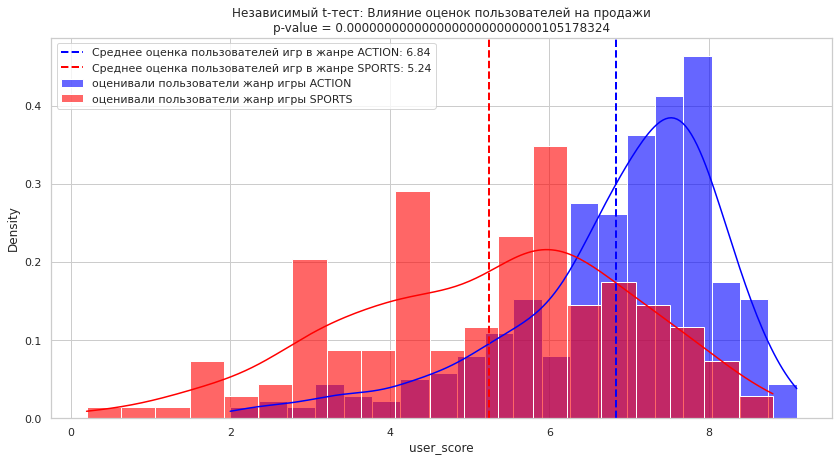

In [152]:
# установка стиля для графиков
sns.set(style="whitegrid")

# визуализация данных
plt.figure(figsize=(14, 7))
sns.histplot(action_u, kde=True, color='blue', label='оценивали пользователи жанр игры ACTION', bins=20, stat="density", alpha=0.6)
sns.histplot(sports_u, kde=True, color='red', label='оценивали пользователи жанр игры SPORTS', bins=20, stat="density", alpha=0.6)
plt.axvline(np.mean(action_u), color='blue', linestyle='dashed', linewidth=2, label=f'Среднее оценка пользователей игр в жанре ACTION: {np.mean(action_u):.2f}')
plt.axvline(np.mean(sports_u), color='red', linestyle='dashed', linewidth=2, label=f'Среднее оценка пользователей игр в жанре SPORTS: {np.mean(sports_u):.2f}')
plt.title(f'Независимый t-тест: Влияние оценок пользователей на продажи\np-value = {p_value:.35f}')
plt.legend()
plt.show()

#### Вывод:
Две гипотезы

- Не отвергаем нулевую гипотезу: недостаточно доказательств, средние пользовательские рейтинги платформ Xbox One и PC равны
- Отвергаем нулевую гипотезу: средние пользовательские рейтинги жанров Action и Sports не равны

Как вы сформулировали нулевую и альтернативную гипотезы
<div class="alert alert-block alert-info">
<b>🔄Комментарий студента:</b> 
Нулевая гипотеза (Н0) предполагает, что различия между сравниваемыми выборками отсутствуют. Её математический смысл состоит в том, что различие между выборками стремится к нулю.

Альтернативная гипотеза (Н1), противостоящая нулевой гипотезе, предполагает, что различия между выборками есть и что они достоверны.
</div>

Какой критерий применили для проверки гипотез и почему.
<div class="alert alert-block alert-info">
<b>🔄Комментарий студента:</b> 
Параметр alternative:
‘two-sided’ (по умолчанию, двусторонний): Проверяет, отличаются ли средние значения двух выборок (независимо от направления). Используется для двусторонней гипотезы.
</div>

### Шаг 6. Напишите общий вывод

По иследовательского анализа данных

- Средний срок жизни платформы 7-8 лет
- Самые перспективные 2 платформы PS4 и Xone
- По графику с усами видно что в топе платформ выделяются x360, ps3, ps4 и xone
- Самый популярный жанр top5 action, самый action, shooter, sports, role-playing и misc	

По анализу в регинах

- Вывод NA:
 - Самые популярные платформы (топ-5). Опишите различия в долях продаж.
  - ps4	xone	x360	ps3	3ds

 - Самые популярные жанры (топ-5). Поясните разницу.
  - action	shooter	sports	role-playing	misc

 - Влияет ли рейтинг ESRB на продажи в отдельном регионе?
  - есть зависимость
  
- Вывод EU:
 - Самые популярные платформы (топ-5). Опишите различия в долях продаж.
  - ps4	ps3	xone x360 3ds
  
 - Самые популярные жанры (топ-5). Поясните разницу.
  -  action	shooter	sports	role-playing	racing

 - Влияет ли рейтинг ESRB на продажи в отдельном регионе?
  - есть зависимость
  
- Вывод JP:
 - Самые популярные платформы (топ-5). Опишите различия в долях продаж.
  - 3ds	ps3	psv	ps4	wiiu

 - Самые популярные жанры (топ-5). Поясните разницу.
  -  role-playing	action	misc	fighting	shooter

 - Влияет ли рейтинг ESRB на продажи в отдельном регионе?
  - есть зависимость
  
- Вывод other:
 - Самые популярные платформы (топ-5). Опишите различия в долях продаж.
  - ps4	ps3	xone	x360	3ds

 - Самые популярные жанры (топ-5). Поясните разницу.
  -  action	shooter	sports	role-playing	misc

 - Влияет ли рейтинг ESRB на продажи в отдельном регионе?
  - есть зависимость

Проверили гипотезы:
- Не отвергаем нулевую гипотезу: недостаточно доказательств, средние пользовательские рейтинги платформ Xbox One и PC равны
- Отвергаем нулевую гипотезу: средние пользовательские рейтинги жанров Action и Sports не равны

Рекомендации:
- Развивать игры по жанрам action,shooter,sports
- жанры для игр 2 платформы PS4 и Xone
- собирать больше оценок критиков на чем выше рейтинг тем выше продоваемость
- ну так же как развивать PS5 и далее.